# Análise e Projeção de Emissão de CO₂ no Brasil
## Ecossistema de Inteligência Computacional para Modelagem Secular

---

### Informações Institucionais
* **Curso:** Bacharelado em Ciência da Computação
* **Instituição:** Faculdade Impacta
* **Ano de Conclusão:** 2026
* **Orientador:** Prof. Vitor Furlan de Oliveira

### Autores
* Gabriel Muchon Pavanelli
* Guilherme Pinheiro dos Santos
* Richard Bernardino Mendes

---

### Volumetria do Pipeline e Performance Limite

O processo de engenharia de dados aplicou filtros estruturais sobre a base histórica do Sistema de Estimativas de Emissões e Remoções de Gases de Efeito Estufa (SEEG), resultando no seguinte funil de dados e score de aderência:

* **454.858** registros originais ingeridos na carga bruta do CSV.
* **38.795** registros consolidados após a filtragem estrita de gases equivalentes e agregação espacial de CO₂.
* **$R^2 = 0,9439$** alcançado pelo melhor modelo preditivo, representando a capacidade limite de explicação da variância histórica do ecossistema.

---


## Escopo do Projeto

Este projeto realiza uma análise preditiva das emissões de CO₂ utilizando técnicas de Ciência de Dados, Machine Learning, Séries Temporais e Inteligência Artificial Explicável (XAI).

### Principais Etapas

- Instalação e configuração do ambiente de desenvolvimento.
- Carregamento, limpeza e preparação dos dados históricos de emissões.
- Análise exploratória dos dados e identificação de padrões temporais.
- Engenharia de atributos e preparação dos conjuntos de treinamento e teste.
- Treinamento e avaliação de modelos de Machine Learning:
  - Regressão Linear;
  - Árvore de Decisão;
  - Random Forest;
  - Support Vector Regression (SVR);
  - Gradient Boosting;
  - K-Nearest Neighbors (KNN);
  - XGBoost;
  - LightGBM.
- Comparação de desempenho por meio de métricas estatísticas e análises gráficas.
- Otimização de hiperparâmetros utilizando Algoritmos Genéticos e Randomized Search.
- Aplicação de modelos de Séries Temporais:
  - ARIMA;
  - SARIMA;
  - Holt-Winters;
  - Prophet.
- Construção de projeções futuras e análise de tendências de longo prazo.
- Comparação entre modelos de aprendizado de máquina e modelos temporais para extrapolação de cenários.
- Avaliação da estabilidade, risco e incerteza das previsões.
- Desenvolvimento de cenários prospectivos para evolução das emissões de CO₂.
- Aplicação de técnicas de Explainable AI (XAI) utilizando SHAP para interpretação dos modelos.

### Objetivo

Identificar os modelos mais adequados para representar o comportamento histórico das emissões de CO₂ e projetar cenários futuros, combinando precisão preditiva, modelagem temporal, otimização computacional e interpretabilidade dos resultados.

In [1]:
# Célula 0 — Instalar bibliotecas necessárias
!pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Célula 1 — Todos os imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [3]:
# Célula 2 — Carregar dados
df_raw = pd.read_csv("br_seeg_emissoes_brasil.csv")
print(f"Dataset original: {df_raw.shape}")
print(f"\nValores únicos de 'gas': {df_raw['gas'].unique()}")
df_raw.head()

Dataset original: (454850, 12)

Valores únicos de 'gas': <StringArray>
[         'CH4 (t)', 'CO2e (t) GTP-AR2', 'CO2e (t) GTP-AR4',
 'CO2e (t) GTP-AR5', 'CO2e (t) GWP-AR2', 'CO2e (t) GWP-AR4',
 'CO2e (t) GWP-AR5',          'N2O (t)',           'CO (t)',
          'NOX (t)',          'CO2 (t)',        'COVNM (t)',
          'NOx (t)',      'HFC-125 (t)',     'HFC-134a (t)',
     'HFC-143a (t)',     'HFC-152a (t)',       'HFC-23 (t)',
       'HFC-32 (t)',         'C2F6 (t)',          'CF4 (t)',
          'SF6 (t)']
Length: 22, dtype: str


,ano,nivel_1,nivel_2,nivel_3,nivel_4,nivel_5,nivel_6,tipo_emissao,gas,atividade_economica,produto,emissao
0,1970,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,230462.17
1,1971,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,226016.30
2,1972,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,220101.20
3,1973,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,214195.56
4,1974,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,186862.84


In [4]:
# Célula 3 — Pipeline de preparação dos dados
'''
    MUDANÇA PRINCIPAL em relação à versão anterior:
    
    Antes: usávamos cada linha individualmente (30795 linhas)
        → cada linha era um sub-setor específico
        → modelos não conseguiam aprender (R² ≈ 0)
    
    Agora: AGREGAMOS as emissões por ANO e SETOR
        → emissão total de CO2 por setor por ano
        → dados mais limpos e com padrão temporal claro
    
    Também criamos uma versão TOTAL (soma de todos os setores)
    para fazer as projeções futuras.
'''

# --- Passo 1: Selecionar colunas ---
df = df_raw[["ano", "nivel_1", "gas", "emissao"]].copy()
print(f"1) Seleção de colunas: {df.shape}")

# --- Passo 2: Filtrar CO2 ---
df = df[df["gas"] == "CO2 (t)"].copy()
print(f"2) Filtro CO2 (t): {df.shape}")

# --- Passo 3: Verificar nulos ---
print(f"\n3) Valores nulos:")
print(df.isnull().sum())

# --- Passo 4: Remover nulos em emissao ---
df = df.dropna(subset=["emissao"])
print(f"\n4) Após remover NaN: {df.shape}")

# --- Passo 5: Remover coluna gas ---
df = df.drop(columns=["gas"])

# --- Passo 6: AGREGAR emissões por ano e setor ---
#     ESTA É A MUDANÇA CHAVE!
#     Somamos todas as emissões de CO2 de cada setor por ano
df_setor = df.groupby(["ano", "nivel_1"])["emissao"].sum().reset_index()
print(f"\n5) Emissões agregadas por ano+setor: {df_setor.shape}")
print(f"   Setores: {df_setor['nivel_1'].unique()}")

# --- Passo 7: Criar dataset TOTAL (soma de todos os setores por ano) ---
#     Este será usado para as PROJEÇÕES FUTURAS
df_total = df.groupby("ano")["emissao"].sum().reset_index()
df_total.columns = ["ano", "emissao_total"]
print(f"\n6) Emissões totais por ano: {df_total.shape}")
print(f"   Anos: {df_total['ano'].min()} a {df_total['ano'].max()}")

# --- Passo 8: One-Hot Encoding no dataset por setor ---
df_modelo = pd.get_dummies(df_setor, columns=["nivel_1"], drop_first=True, dtype=int)
print(f"\n7) Após One-Hot Encoding: {df_modelo.shape}")
print(f"   Colunas: {list(df_modelo.columns)}")

# --- Verificação ---
print(f"\n{'->x<-'*10}")
print(f"   Dados prontos!")
print(f"   Dataset modelo (por setor): {df_modelo.shape}")
print(f"   Dataset total (projeções):  {df_total.shape}")
print(f"{'->x<-'*10}")

df_modelo.head(10)


1) Seleção de colunas: (454850, 4)
2) Filtro CO2 (t): (37550, 4)

3) Valores nulos:
ano           0
nivel_1       0
gas           0
emissao    6755
dtype: int64

4) Após remover NaN: (30795, 4)

5) Emissões agregadas por ano+setor: (250, 3)
   Setores: <StringArray>
[                      'Agropecuária',                            'Energia',
 'Mudança de Uso da Terra e Floresta',              'Processos Industriais',
                          'Resíduos ']
Length: 5, dtype: str

6) Emissões totais por ano: (50, 2)
   Anos: 1970 a 2019

7) Após One-Hot Encoding: (250, 6)
   Colunas: ['ano', 'emissao', 'nivel_1_Energia', 'nivel_1_Mudança de Uso da Terra e Floresta', 'nivel_1_Processos Industriais', 'nivel_1_Resíduos ']

->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
   Dados prontos!
   Dataset modelo (por setor): (250, 6)
   Dataset total (projeções):  (50, 2)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-


,ano,emissao,nivel_1_Energia,nivel_1_Mudança de Uso da Terra e Floresta,nivel_1_Processos Industriais,nivel_1_Resíduos
0,1970,9.716176e+05,0,0,0,0
1,1970,7.632403e+07,1,0,0,0
2,1970,0.000000e+00,0,1,0,0
3,1970,1.131884e+07,0,0,1,0
4,1970,1.488171e+05,0,0,0,1
5,1971,1.393503e+06,0,0,0,0
6,1971,8.652302e+07,1,0,0,0
7,1971,0.000000e+00,0,1,0,0
8,1971,1.182835e+07,0,0,1,0
9,1971,1.448152e+05,0,0,0,1


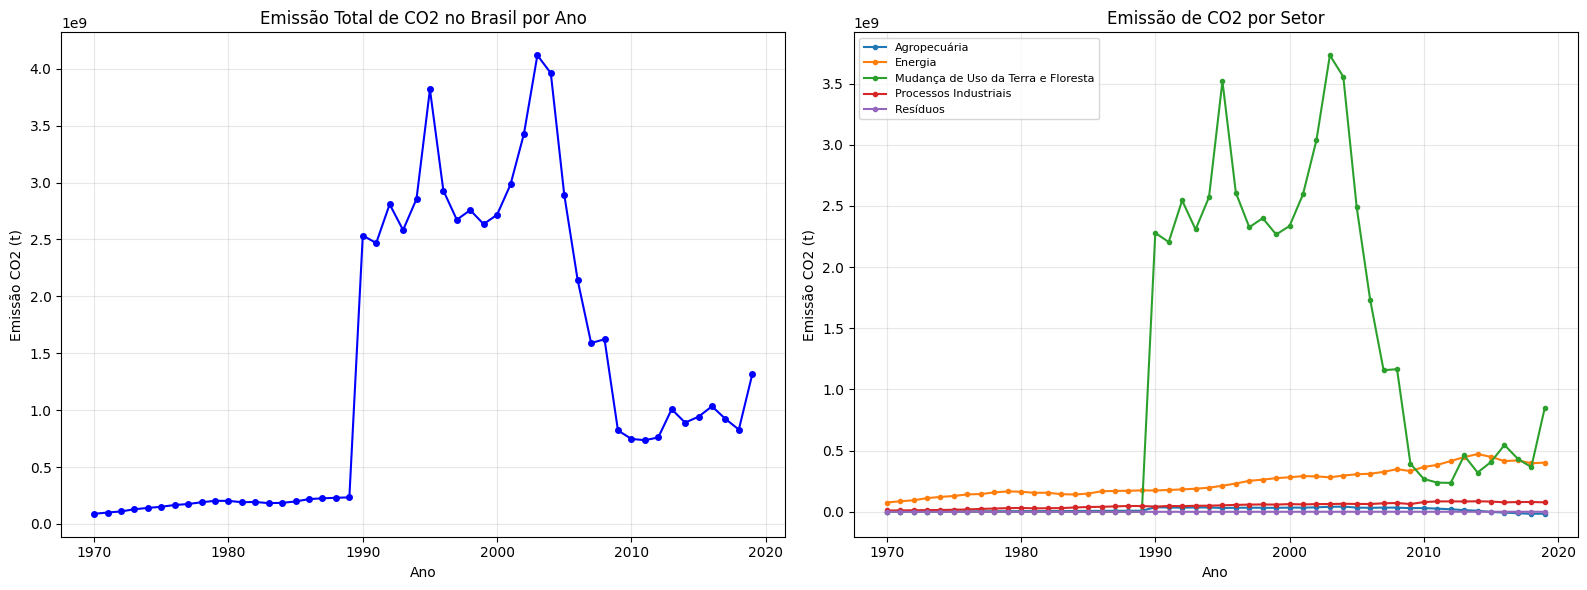

Observe os padrões temporais — isso é o que os modelos vão aprender!


In [5]:
# Célula 4 — Visualizar dados antes de modelar
'''
    Sempre bom visualizar os dados antes de treinar modelos.
    Isso ajuda a entender padrões e verificar se os dados
    fazem sentido.
'''

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Emissão total por ano
axes[0].plot(df_total["ano"], df_total["emissao_total"], "b-o", markersize=4)
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Emissão CO2 (t)")
axes[0].set_title("Emissão Total de CO2 no Brasil por Ano")
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Emissão por setor
for setor in df_setor["nivel_1"].unique():
    dados = df_setor[df_setor["nivel_1"] == setor]
    axes[1].plot(dados["ano"], dados["emissao"], "-o", markersize=3, label=setor)

axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Emissão CO2 (t)")
axes[1].set_title("Emissão de CO2 por Setor")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observe os padrões temporais — isso é o que os modelos vão aprender!")


In [6]:
# Célula 5 — Separar X e y + Normalização
'''
    Separamos features (X) e target (y) do dataset por setor.
    Depois normalizamos tudo para [0, 1].
'''

# Separar
X = df_modelo.drop(columns=["emissao"])
y = df_modelo["emissao"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

# Normalizar X
scaler_X = MinMaxScaler()
X = pd.DataFrame(
    scaler_X.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Normalizar y
scaler_y = MinMaxScaler()
y = pd.Series(
    scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten(),
    index=y.index,
    name="emissao"
)

# Verificações
assert X.shape[0] == y.shape[0], "❌ X e y com tamanhos diferentes!"
assert y.shape[0] > 0, "❌ y está vazio!"

print(f"\nX range: [{X.min().min():.4f}, {X.max().max():.4f}]")
print(f"y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"\n{X.shape[0]} amostras, {X.shape[1]} features — prontos!")


X shape: (250, 5)
y shape: (250,)
Features: ['ano', 'nivel_1_Energia', 'nivel_1_Mudança de Uso da Terra e Floresta', 'nivel_1_Processos Industriais', 'nivel_1_Resíduos ']

X range: [0.0000, 1.0000]
y range: [0.0000, 1.0000]

250 amostras, 5 features — prontos!


In [7]:
# Célula 6 — Divisão treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Teste:  X={X_test.shape},  y={y_test.shape}")
print(f"\nDivisão 80/20 concluída!")


Treino: X=(200, 5), y=(200,)
Teste:  X=(50, 5),  y=(50,)

Divisão 80/20 concluída!


In [8]:
# Célula 7 — Função de avaliação (atualizada)

def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    """Treina o modelo, faz predições e exibe métricas."""
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"{'->x<-'*10}")
    print(f"  {nome}")
    print(f"{'->x<-'*10}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  R²:   {r2:.6f}")
    
    # Interpretar o R²
    if r2 >= 0.9:
        print(f"  → Excelente! 🟢")
    elif r2 >= 0.7:
        print(f"  → Bom 🟡")
    elif r2 >= 0.5:
        print(f"  → Razoável 🟠")
    else:
        print(f"  → Fraco 🔴")
    print()
    
    return {
        "nome": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "y_pred": y_pred,
        "modelo": modelo
    }

print("Função avaliar_modelo() definida!")


Função avaliar_modelo() definida!


In [9]:
# Célula 8 — Modelo 1: Regressão Linear Múltipla (MLR)
'''
    Encontra a melhor combinação linear das features.
    y = b0 + b1*x1 + b2*x2 + ... + bn*xn
    
    Simples e rápido, mas assume relação LINEAR entre
    as variáveis — pode não capturar padrões complexos.
'''

res_mlr = avaliar_modelo(
    "Regressão Linear Múltipla",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Regressão Linear Múltipla
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.064652
  RMSE: 0.118798
  R²:   0.425449
  → Fraco 🔴



In [10]:
# Célula 9 — Modelo 2: Árvore de Regressão
'''
    Divide os dados em regiões usando regras de decisão.
    Simples e interpretável, mas pode overfittar (decorar
    os dados de treino sem generalizar).
'''

res_arvore = avaliar_modelo(
    "Árvore de Regressão",
    DecisionTreeRegressor(random_state=42, max_depth=10),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Árvore de Regressão
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.016422
  RMSE: 0.054950
  R²:   0.877074
  → Bom 🟡



In [ ]:
# Célula 10 — Modelo 3: Floresta Aleatória de Regressão
'''
    Combina várias árvores de decisão (ensemble).
    Cada árvore vê uma parte aleatória dos dados.
    O resultado final é a MÉDIA das predições de todas as árvores.
    Reduz o overfitting em relação a uma árvore só.
'''

res_floresta = avaliar_modelo(
    "Floresta Aleatória",
    RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Floresta Aleatória
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.013291
  RMSE: 0.037629
  R²:   0.942356
  → Excelente! 🟢



In [12]:
# Célula 11 — Modelo 4: SVR (Support Vector Regression)
'''
    Encontra um hiperplano que melhor se ajusta aos dados
    dentro de uma margem de tolerância (epsilon).
    
    Usa o kernel RBF (Radial Basis Function) que permite
    capturar relações não-lineares.
    
    MUITO sensível à escala — por isso normalizamos antes.
    
    One-Hot Encoding é necessário para SVR porque ele não
    aceita variáveis categóricas — precisa de tudo numérico.
'''

res_svr = avaliar_modelo(
    "SVR (Support Vector Regression)",
    SVR(kernel="rbf", C=10.0, epsilon=0.01, gamma="scale"),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  SVR (Support Vector Regression)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.038338
  RMSE: 0.095781
  R²:   0.626521
  → Razoável 🟠



In [13]:
# Célula 12 — Modelo 5: Gradient Boosting Regression
'''
    Constrói árvores SEQUENCIALMENTE — cada nova árvore
    corrige os erros da anterior (boosting).
    Geralmente um dos modelos mais precisos.
'''

res_gbr = avaliar_modelo(
    "Gradient Boosting",
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Gradient Boosting
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.016510
  RMSE: 0.054834
  R²:   0.877592
  → Bom 🟡



In [14]:
# Célula 13 — Modelo 6: KNN Regressor (NOVO!)
'''
    K-Nearest Neighbors Regression.
    Para prever um valor, olha os K vizinhos mais próximos
    no espaço das features e calcula a média dos seus valores.
    
    Simples e intuitivo. Funciona bem quando dados similares
    têm valores de emissão similares.
'''

res_knn = avaliar_modelo(
    "KNN Regressor",
    KNeighborsRegressor(n_neighbors=5, weights="distance"),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  KNN Regressor
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.012101
  RMSE: 0.043621
  R²:   0.922536
  → Excelente! 🟢



In [15]:
# Célula 14 — Ranking comparativo dos modelos

todos_resultados = [res_mlr, res_arvore, res_floresta, res_svr, res_gbr, res_knn]

resultados = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_pred", "modelo"]}
    for r in todos_resultados
])

# Ordenar pelo R² (maior = melhor)
resultados = resultados.sort_values("R2", ascending=False).reset_index(drop=True)

print("->x<-" * 15)
print("  RANKING DOS MODELOS (ordenado por R²)")
print("->x<-" * 15)
print(resultados.to_string(index=False))
print("->x<-" * 15)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  RANKING DOS MODELOS (ordenado por R²)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
                           nome      MAE     RMSE       R2
             Floresta Aleatória 0.013291 0.037629 0.942356
                  KNN Regressor 0.012101 0.043621 0.922536
              Gradient Boosting 0.016510 0.054834 0.877592
            Árvore de Regressão 0.016422 0.054950 0.877074
SVR (Support Vector Regression) 0.038338 0.095781 0.626521
      Regressão Linear Múltipla 0.064652 0.118798 0.425449
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-


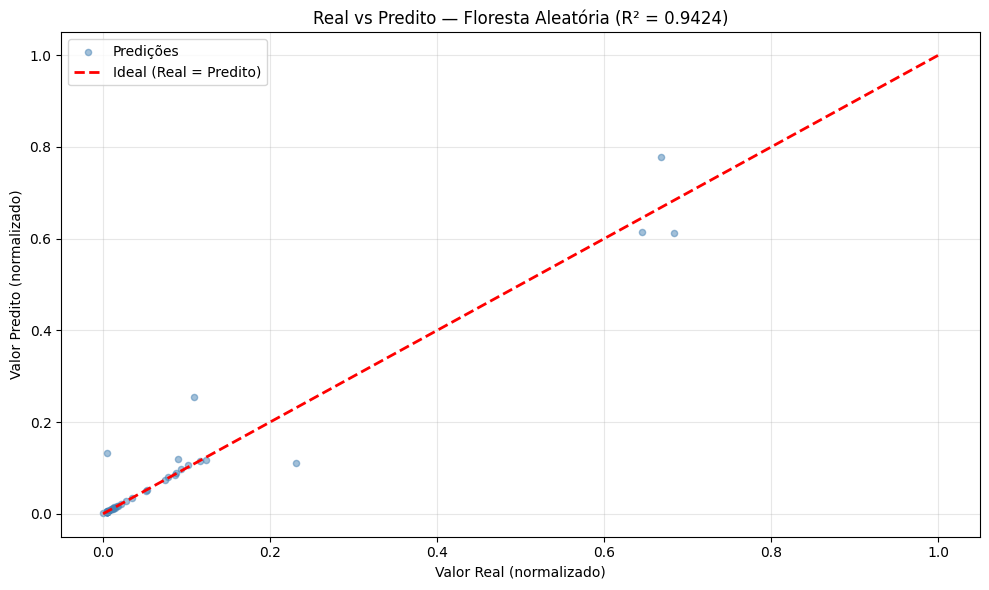

In [16]:
# Célula 15 — Gráfico Real vs Predito (melhor modelo)

melhor_nome = resultados.iloc[0]["nome"]

preds = {r["nome"]: r for r in todos_resultados}
y_pred_melhor = preds[melhor_nome]["y_pred"]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_melhor, alpha=0.5, s=20, color="steelblue", label="Predições")
plt.plot([0, 1], [0, 1], "r--", linewidth=2, label="Ideal (Real = Predito)")
plt.xlabel("Valor Real (normalizado)")
plt.ylabel("Valor Predito (normalizado)")
plt.title(f"Real vs Predito — {melhor_nome} (R² = {resultados.iloc[0]['R2']:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

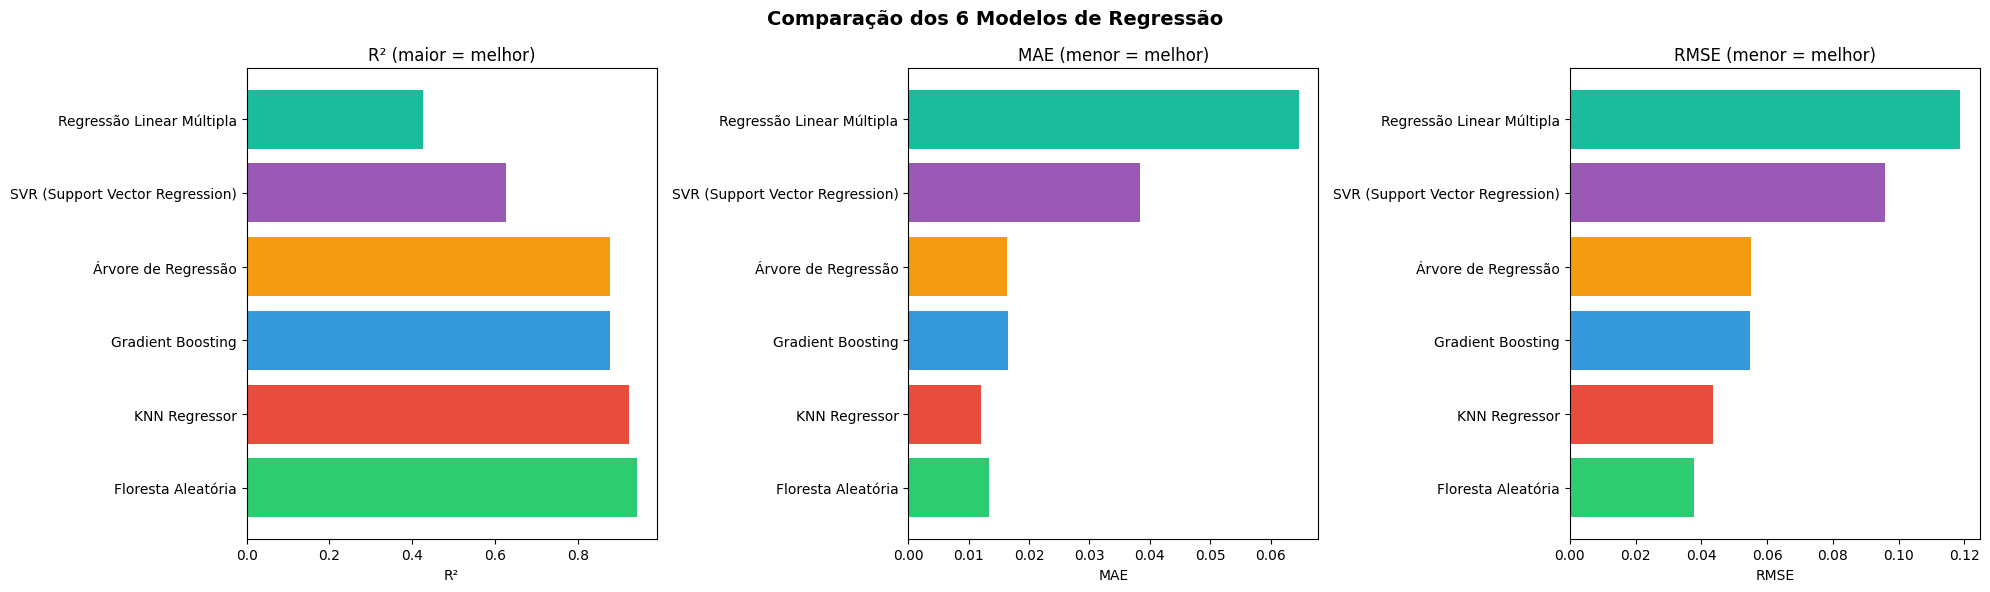

In [17]:
# Célula 16 — Gráfico de barras comparativo

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cores = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6", "#1abc9c"]

# R²
axes[0].barh(resultados["nome"], resultados["R2"], color=cores[:len(resultados)])
axes[0].set_xlabel("R²")
axes[0].set_title("R² (maior = melhor)")

# MAE
axes[1].barh(resultados["nome"], resultados["MAE"], color=cores[:len(resultados)])
axes[1].set_xlabel("MAE")
axes[1].set_title("MAE (menor = melhor)")

# RMSE
axes[2].barh(resultados["nome"], resultados["RMSE"], color=cores[:len(resultados)])
axes[2].set_xlabel("RMSE")
axes[2].set_title("RMSE (menor = melhor)")

plt.suptitle("Comparação dos 6 Modelos de Regressão", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [18]:
# Célula 17 — PROJEÇÕES FUTURAS: Preparação
'''
    OBJETIVO PRINCIPAL DO PROJETO:
    
    "Se nada mudar no cenário atual, como ficaria a emissão
    de CO2 daqui 10, 30, 50, 100, 300 e 500 anos?"
    
    Usamos o dataset TOTAL (emissão por ano) e treinamos
    vários modelos para projetar o futuro.
    
    Como temos apenas 1 feature (ano), adicionamos features
    polinomiais para capturar tendências não-lineares:
    - ano² (tendência quadrática)
    - ano³ (tendência cúbica)
'''

# Preparar dados para projeção
X_total = df_total[["ano"]].values
y_total = df_total["emissao_total"].values

# Adicionar features polinomiais (ano², ano³)
# Isso permite capturar tendências não-lineares
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_total)

print(f"Features originais: ano")
print(f"Features polinomiais: ano, ano², ano³")
print(f"X_poly shape: {X_poly.shape}")
print(f"Anos disponíveis: {df_total['ano'].min()} a {df_total['ano'].max()}")
print(f"\nDados de emissão total:")
print(df_total.tail(10))


Features originais: ano
Features polinomiais: ano, ano², ano³
X_poly shape: (50, 3)
Anos disponíveis: 1970 a 2019

Dados de emissão total:
     ano  emissao_total
40  2010   7.471605e+08
41  2011   7.356911e+08
42  2012   7.594675e+08
43  2013   1.008120e+09
44  2014   8.899871e+08
45  2015   9.422020e+08
46  2016   1.033447e+09
47  2017   9.231357e+08
48  2018   8.290037e+08
49  2019   1.314751e+09


In [19]:
# Célula 18 — PROJEÇÕES: Treinar todos os modelos
# ============================================================
'''
    Treinamos cada modelo com TODOS os dados históricos
    (sem split treino/teste) porque queremos a melhor
    projeção possível para o futuro.
    
    Depois avaliamos qual modelo se ajusta melhor aos
    dados históricos (R² no treino).
'''

# Definir anos futuros para projeção
ano_atual = df_total["ano"].max()
anos_projecao = [
    ano_atual + 10,   # ~2029
    ano_atual + 30,   # ~2049
    ano_atual + 50,   # ~2069
    ano_atual + 100,  # ~2119
    ano_atual + 300,  # ~2319
    ano_atual + 500,  # ~2519
]

print(f"Ano mais recente nos dados: {ano_atual}")
print(f"Anos para projeção: {anos_projecao}")

# Dicionário para guardar modelos e projeções
modelos_projecao = {}

# Lista de modelos para projeção
lista_modelos = [
    ("Regressão Linear", LinearRegression()),
    ("Árvore de Regressão", DecisionTreeRegressor(random_state=42, max_depth=5)),
    ("Floresta Aleatória", RandomForestRegressor(n_estimators=200, random_state=42)),
    ("SVR", SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("KNN", KNeighborsRegressor(n_neighbors=3, weights="distance")),
]

print(f"\n{'='*60}")
print(f"  Treinando modelos para projeção...")
print(f"{'='*60}\n")

for nome, modelo in lista_modelos:
    # Treinar com TODOS os dados históricos
    modelo.fit(X_poly, y_total)
    
    # R² no treino (quão bem se ajusta aos dados históricos)
    y_pred_treino = modelo.predict(X_poly)
    r2_treino = r2_score(y_total, y_pred_treino)
    
    # Gerar projeções
    anos_futuros = np.array(anos_projecao).reshape(-1, 1)
    X_futuro_poly = poly.transform(anos_futuros)
    projecoes = modelo.predict(X_futuro_poly)
    
    # Guardar
    modelos_projecao[nome] = {
        "modelo": modelo,
        "r2_treino": r2_treino,
        "projecoes": projecoes,
    }
    
    print(f"  {nome:25s} | R² treino: {r2_treino:.6f}")

print(f"\nTodos os modelos treinados!")


Ano mais recente nos dados: 2019
Anos para projeção: [np.int64(2029), np.int64(2049), np.int64(2069), np.int64(2119), np.int64(2319), np.int64(2519)]

  Treinando modelos para projeção...

  Regressão Linear          | R² treino: 0.508678
  Árvore de Regressão       | R² treino: 0.991938
  Floresta Aleatória        | R² treino: 0.987293
  SVR                       | R² treino: -0.146457
  Gradient Boosting         | R² treino: 0.999999
  KNN                       | R² treino: 1.000000

Todos os modelos treinados!


In [20]:
# Célula 19 — PROJEÇÕES: Tabela comparativa
'''
    Tabela mostrando a projeção de cada modelo para cada
    horizonte temporal.
    
    Valores em TONELADAS de CO2.
'''

# Criar tabela de projeções
tabela = {"Ano": anos_projecao}
for nome, dados in modelos_projecao.items():
    tabela[nome] = dados["projecoes"]

df_projecoes = pd.DataFrame(tabela)

# Adicionar coluna de "daqui a X anos"
df_projecoes.insert(1, "Horizonte", [
    f"+{a - ano_atual} anos" for a in anos_projecao
])

print("->x<-" * 100)
print("  PROJEÇÕES DE EMISSÃO DE CO2 (toneladas) — SE NADA MUDAR")
print("->x<-" * 100)

# Formatar números grandes
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print(df_projecoes.to_string(index=False))
pd.reset_option("display.float_format")

print("->x<-" * 100)

# Emissão atual para referência
emissao_atual = df_total[df_total["ano"] == ano_atual]["emissao_total"].values[0]
print(f"\nEmissão atual ({ano_atual}): {emissao_atual:,.0f} toneladas de CO2")


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  PROJEÇÕES DE EMISSÃO DE CO2 (toneladas) — SE NADA MUDAR
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<--

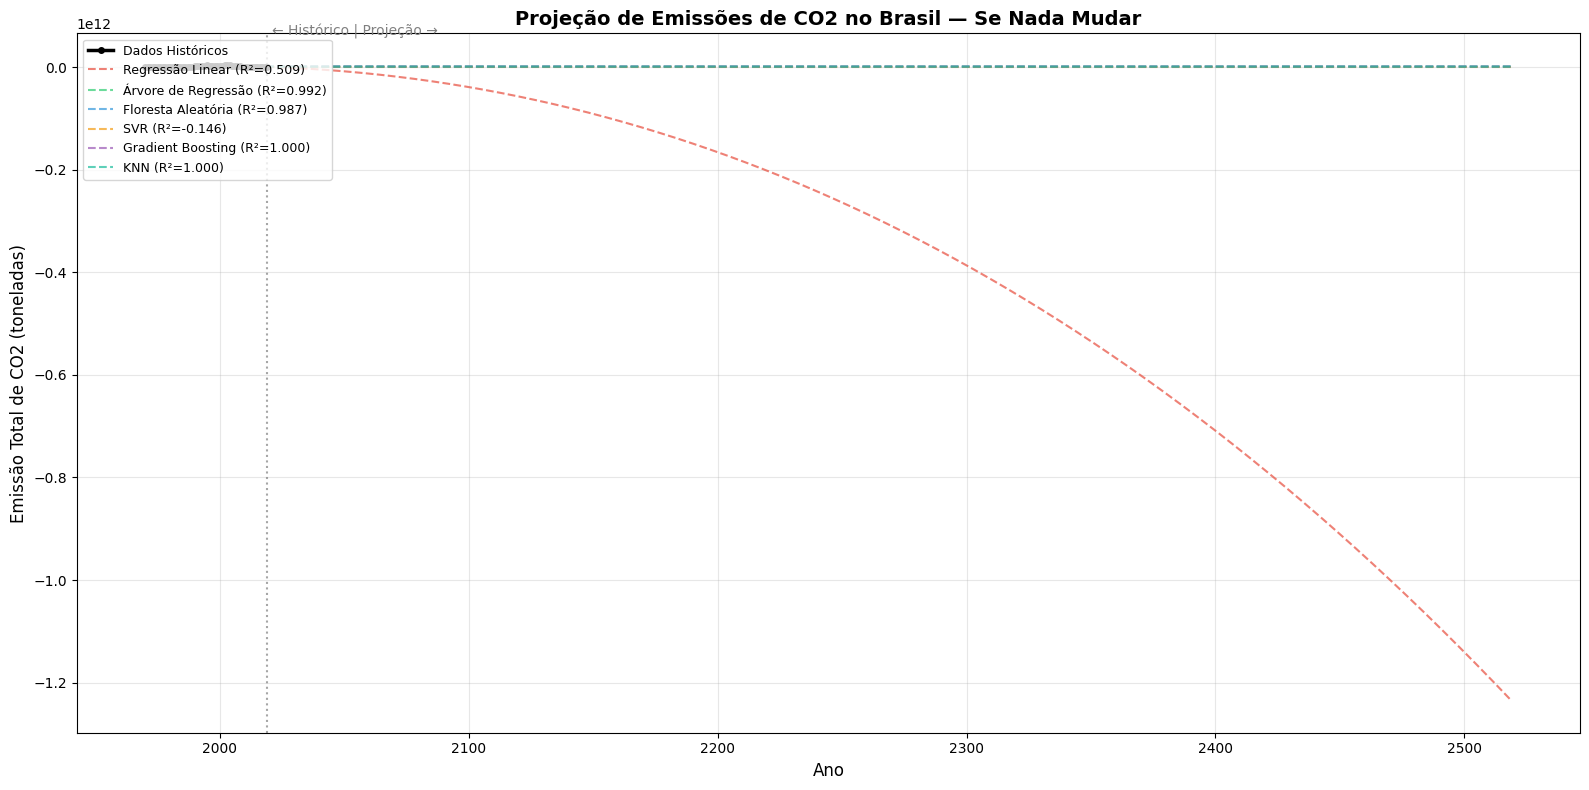

In [21]:
# Célula 20 — GRÁFICO 1: Histórico + Projeções (todos os modelos)
'''
    Gráfico principal: mostra os dados históricos reais
    e as projeções de cada modelo até o futuro.
'''

plt.figure(figsize=(16, 8))

# Dados históricos (linha preta grossa)
plt.plot(
    df_total["ano"], df_total["emissao_total"],
    "k-o", linewidth=2.5, markersize=4, label="Dados Históricos", zorder=5
)

# Gerar curvas suaves para cada modelo
anos_continuo = np.arange(df_total["ano"].min(), max(anos_projecao) + 1, 1).reshape(-1, 1)
X_continuo_poly = poly.transform(anos_continuo)

cores_modelos = {
    "Regressão Linear": "#e74c3c",
    "Árvore de Regressão": "#2ecc71",
    "Floresta Aleatória": "#3498db",
    "SVR": "#f39c12",
    "Gradient Boosting": "#9b59b6",
    "KNN": "#1abc9c",
}

for nome, dados in modelos_projecao.items():
    modelo = dados["modelo"]
    y_continuo = modelo.predict(X_continuo_poly)
    
    plt.plot(
        anos_continuo, y_continuo,
        "--", linewidth=1.5, alpha=0.7,
        color=cores_modelos[nome],
        label=f"{nome} (R²={dados['r2_treino']:.3f})"
    )

# Linha vertical separando histórico de projeção
plt.axvline(x=ano_atual, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
plt.text(ano_atual + 2, plt.ylim()[1] * 0.95, "← Histórico | Projeção →",
        fontsize=10, color="gray")

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Emissão Total de CO2 (toneladas)", fontsize=12)
plt.title("Projeção de Emissões de CO2 no Brasil — Se Nada Mudar", fontsize=14, fontweight="bold")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


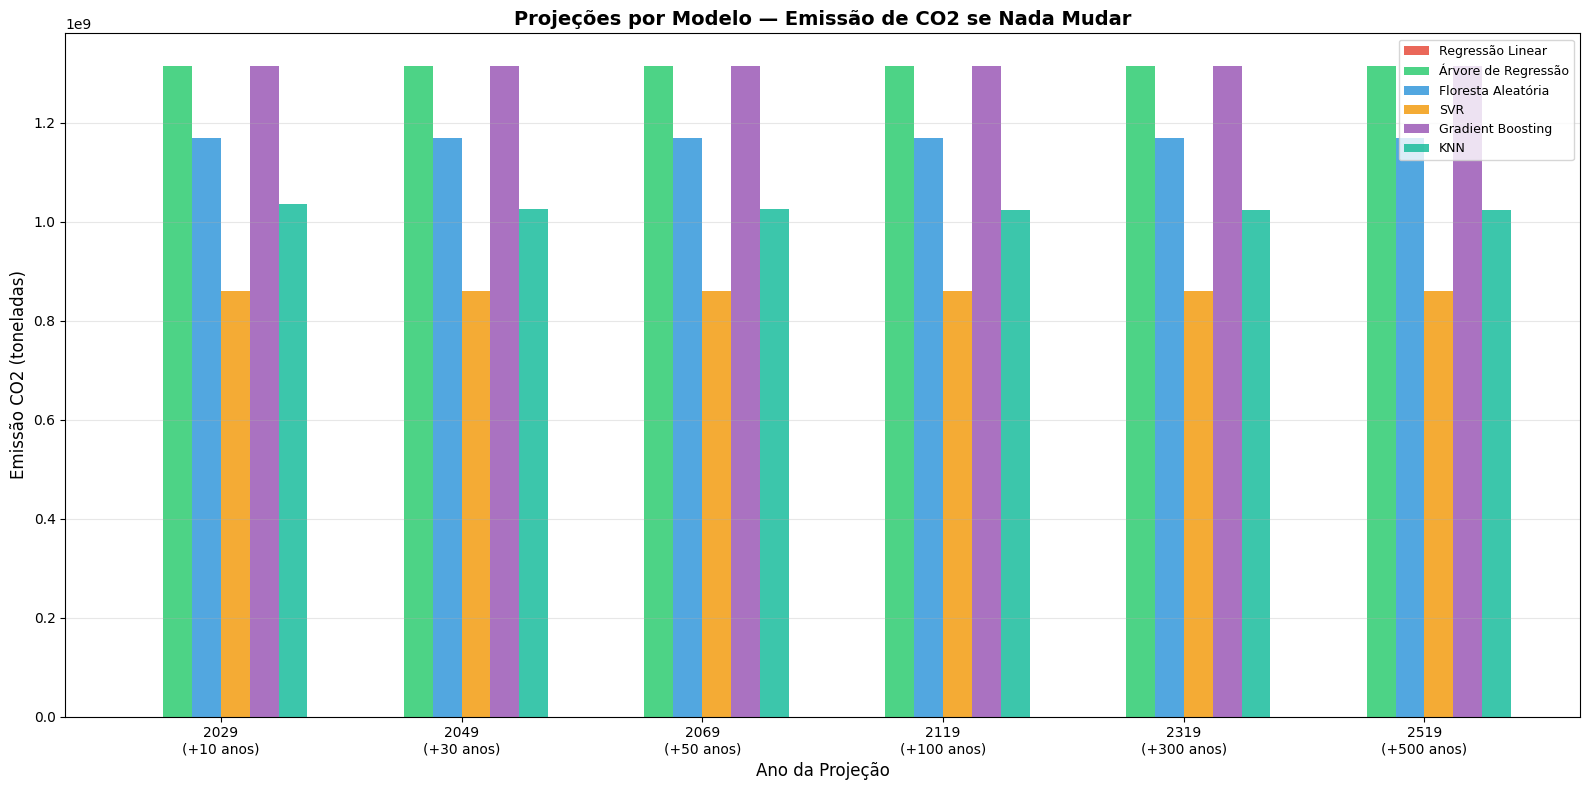

In [22]:
# Célula 21 — GRÁFICO 2: Projeções focado (apenas futuro)
'''
    Gráfico de barras agrupadas mostrando a projeção de cada
    modelo para cada horizonte temporal.
'''

fig, ax = plt.subplots(figsize=(16, 8))

n_modelos = len(modelos_projecao)
n_horizontes = len(anos_projecao)
largura = 0.12
x = np.arange(n_horizontes)

horizontes = [f"{a}\n(+{a - ano_atual} anos)" for a in anos_projecao]

for i, (nome, dados) in enumerate(modelos_projecao.items()):
    valores = dados["projecoes"]
    # Limitar valores negativos a zero (emissão não pode ser negativa)
    valores = np.maximum(valores, 0)
    
    ax.bar(
        x + i * largura,
        valores,
        largura,
        label=nome,
        color=list(cores_modelos.values())[i],
        alpha=0.85
    )

ax.set_xlabel("Ano da Projeção", fontsize=12)
ax.set_ylabel("Emissão CO2 (toneladas)", fontsize=12)
ax.set_title("Projeções por Modelo — Emissão de CO2 se Nada Mudar", fontsize=14, fontweight="bold")
ax.set_xticks(x + largura * (n_modelos - 1) / 2)
ax.set_xticklabels(horizontes)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


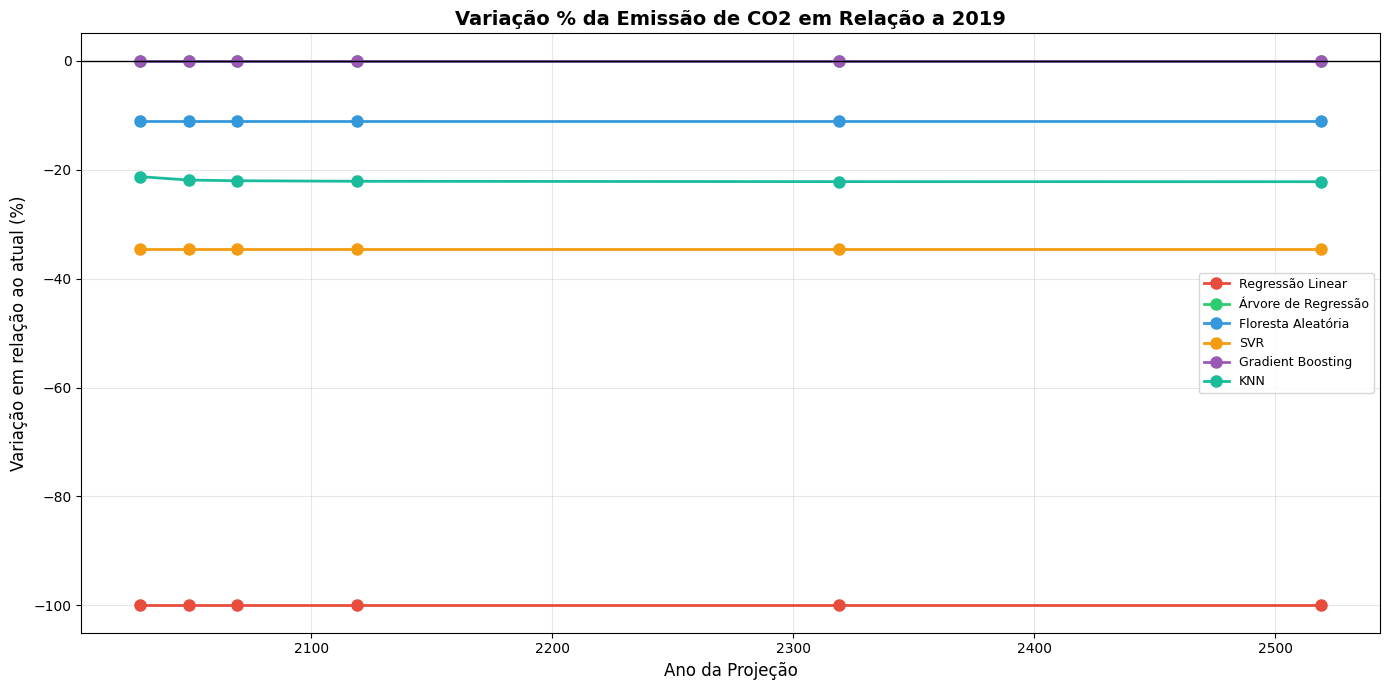

In [23]:
# Célula 22 — GRÁFICO 3: Variação percentual em relação ao atual
'''
    Mostra o AUMENTO PERCENTUAL da emissão em relação ao
    valor atual, facilitando a interpretação.
'''

emissao_atual = df_total[df_total["ano"] == ano_atual]["emissao_total"].values[0]

fig, ax = plt.subplots(figsize=(14, 7))

for nome, dados in modelos_projecao.items():
    projecoes = np.maximum(dados["projecoes"], 0)  # Sem negativos
    variacao_pct = ((projecoes - emissao_atual) / emissao_atual) * 100
    
    ax.plot(
        anos_projecao, variacao_pct,
        "-o", linewidth=2, markersize=8,
        color=cores_modelos[nome],
        label=nome
    )

ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Ano da Projeção", fontsize=12)
ax.set_ylabel("Variação em relação ao atual (%)", fontsize=12)
ax.set_title(f"Variação % da Emissão de CO2 em Relação a {ano_atual}", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
# # Célula 23 — GRÁFICO 4: Emissão por SETOR — histórico
# '''
#     Mostra a contribuição de cada setor ao longo do tempo.
#     Gráfico de área empilhada — permite ver qual setor
#     contribui mais e como isso muda ao longo dos anos.
# '''

# # Pivotar dados por setor
# df_pivot = df_setor.pivot_table(
#     index="ano", columns="nivel_1", values="emissao", aggfunc="sum"
# ).fillna(0)

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# # Área empilhada
# df_pivot.plot.area(ax=axes[0], alpha=0.7, linewidth=0.5)
# axes[0].set_xlabel("Ano")
# axes[0].set_ylabel("Emissão CO2 (t)")
# axes[0].set_title("Emissão de CO2 por Setor — Área Empilhada")
# axes[0].legend(fontsize=8, loc="upper left")
# axes[0].grid(True, alpha=0.3)

# # Linhas separadas
# for col in df_pivot.columns:
#     axes[1].plot(df_pivot.index, df_pivot[col], "-o", markersize=3, label=col)

# axes[1].set_xlabel("Ano")
# axes[1].set_ylabel("Emissão CO2 (t)")
# axes[1].set_title("Emissão de CO2 por Setor — Linhas")
# axes[1].legend(fontsize=8)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()


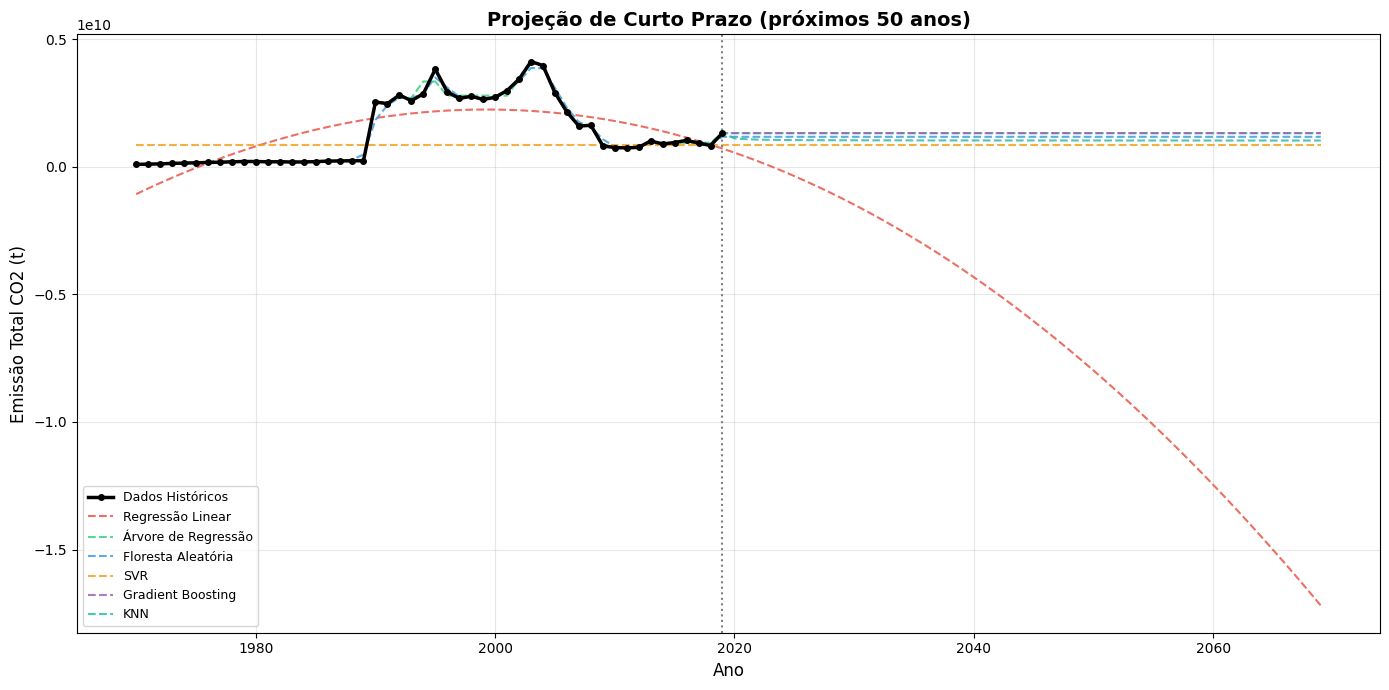

In [25]:
# Célula 24 — GRÁFICO 5: Projeção curto prazo (próximos 50 anos)
'''
    Zoom nas projeções de curto prazo (mais confiáveis).
    Projeções muito distantes (300-500 anos) são especulativas.
'''

plt.figure(figsize=(14, 7))

# Histórico
plt.plot(
    df_total["ano"], df_total["emissao_total"],
    "k-o", linewidth=2.5, markersize=4, label="Dados Históricos", zorder=5
)

# Projeções apenas até +50 anos
anos_curto = np.arange(df_total["ano"].min(), ano_atual + 51, 1).reshape(-1, 1)
X_curto_poly = poly.transform(anos_curto)

for nome, dados in modelos_projecao.items():
    modelo = dados["modelo"]
    y_curto = modelo.predict(X_curto_poly)
    
    plt.plot(
        anos_curto, y_curto,
        "--", linewidth=1.5, alpha=0.8,
        color=cores_modelos[nome],
        label=f"{nome}"
    )

plt.axvline(x=ano_atual, color="gray", linestyle=":", linewidth=1.5)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Emissão Total CO2 (t)", fontsize=12)
plt.title("Projeção de Curto Prazo (próximos 50 anos)", fontsize=14, fontweight="bold")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
# Célula 25 — RESUMO FINAL DO PROJETO
'''
    Resumo consolidado de tudo que foi feito no projeto.
'''

print("=" * 70)
print("  RESUMO FINAL DO PROJETO")
print("  Análise e Projeção de Emissões de CO2 no Brasil")
print("=" * 70)

print(f"\n📁 DADOS:")
print(f"   Dataset: br_seeg_emissoes_brasil.csv")
print(f"   Registros originais: {df_raw.shape[0]:,}")
print(f"   Filtro aplicado: apenas CO2 (t)")
print(f"   Período: {df_total['ano'].min()} a {df_total['ano'].max()}")
print(f"   Emissão atual ({ano_atual}): {emissao_atual:,.0f} toneladas")

print(f"\n🔧 PRÉ-PROCESSAMENTO:")
print(f"   ✓ Verificação de valores nulos (NaN)")
print(f"   ✓ Remoção de NaN na coluna emissao")
print(f"   ✓ One-Hot Encoding (nivel_1 → dummies)")
print(f"   ✓ Normalização Min-Max [0, 1]")
print(f"   ✓ Agregação por ano e setor")

print(f"\n🤖 MODELOS DE REGRESSÃO (ranking por R²):")
print(resultados.to_string(index=False))

print(f"\n🔮 PROJEÇÕES (se nada mudar):")
for nome, dados in modelos_projecao.items():
    print(f"\n   {nome} (R² treino: {dados['r2_treino']:.4f}):")
    for i, ano in enumerate(anos_projecao):
        valor = max(dados["projecoes"][i], 0)
        variacao = ((valor - emissao_atual) / emissao_atual) * 100
        print(f"     {ano} (+{ano - ano_atual:3d} anos): {valor:>15,.0f} t  ({variacao:+.1f}%)")

print(f"\n{'='*70}")
print(f"  ⚠️  NOTA: Projeções assumem que tendências históricas se mantêm.")
print(f"  Fatores como políticas climáticas, tecnologia e desmatamento")
print(f"  podem alterar significativamente esses cenários.")
print(f"{'='*70}")

  RESUMO FINAL DO PROJETO
  Análise e Projeção de Emissões de CO2 no Brasil

📁 DADOS:
   Dataset: br_seeg_emissoes_brasil.csv
   Registros originais: 454,850
   Filtro aplicado: apenas CO2 (t)
   Período: 1970 a 2019
   Emissão atual (2019): 1,314,750,823 toneladas

🔧 PRÉ-PROCESSAMENTO:
   ✓ Verificação de valores nulos (NaN)
   ✓ Remoção de NaN na coluna emissao
   ✓ One-Hot Encoding (nivel_1 → dummies)
   ✓ Normalização Min-Max [0, 1]
   ✓ Agregação por ano e setor

🤖 MODELOS DE REGRESSÃO (ranking por R²):
                           nome      MAE     RMSE       R2
             Floresta Aleatória 0.013291 0.037629 0.942356
                  KNN Regressor 0.012101 0.043621 0.922536
              Gradient Boosting 0.016510 0.054834 0.877592
            Árvore de Regressão 0.016422 0.054950 0.877074
SVR (Support Vector Regression) 0.038338 0.095781 0.626521
      Regressão Linear Múltipla 0.064652 0.118798 0.425449

🔮 PROJEÇÕES (se nada mudar):

   Regressão Linear (R² treino: 0.5087):
 

In [30]:
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Verificação de segurança

if (
    "X_train" not in globals()
    or "X_test" not in globals()
    or "y_train" not in globals()
    or "y_test" not in globals()
):
    print("ERRO: Execute primeiro a célula que cria X_train, X_test, y_train e y_test.")

elif "avaliar_modelo" not in globals():
    print("ERRO: A função avaliar_modelo() não foi encontrada.")

else:

    random.seed(42)
    np.random.seed(42)

    # Algoritmo Genético genérico para otimização de hiperparâmetros

    def otimizar_modelo_ag(model_class, limites):

        TAMANHO_POPULACAO = 30
        GERACOES = 20
        TAXA_CRUZAMENTO = 0.8
        TAXA_MUTACAO = 0.1
        ELITISMO_TAM = 2

        def avaliar(individuo):

            params = {}

            for param, valor in individuo.items():

                if param in [
                    "n_estimators",
                    "max_depth",
                    "n_neighbors"
                ]:
                    params[param] = int(round(valor))
                else:
                    params[param] = valor

            try:

                modelo = model_class(**params)

                scores = cross_val_score(
                    modelo,
                    X_train,
                    y_train,
                    cv=3,
                    scoring="r2"
                )

                return scores.mean()

            except Exception:
                return -9999

        populacao = []

        for _ in range(TAMANHO_POPULACAO):

            individuo = {}

            for param, (minimo, maximo) in limites.items():

                individuo[param] = random.uniform(
                    minimo,
                    maximo
                )

            populacao.append(individuo)

        for geracao in range(GERACOES):

            for individuo in populacao:

                if "fitness" not in individuo:

                    individuo["fitness"] = avaliar(
                        individuo
                    )

            populacao.sort(
                key=lambda x: x["fitness"],
                reverse=True
            )

            if geracao % 5 == 0:

                print(
                    f"Geração {geracao} | Melhor R² = {populacao[0]['fitness']:.4f}"
                )

            nova_pop = populacao[:ELITISMO_TAM]

            while len(nova_pop) < TAMANHO_POPULACAO:

                pai1 = random.choice(populacao[:10])
                pai2 = random.choice(populacao[:10])

                filho = {}

                for param in limites:

                    if random.random() < TAXA_CRUZAMENTO:

                        alpha = random.random()

                        filho[param] = (
                            alpha * pai1[param]
                            + (1 - alpha) * pai2[param]
                        )

                    else:

                        filho[param] = pai1[param]

                    if random.random() < TAXA_MUTACAO:

                        minimo, maximo = limites[param]

                        sigma = (
                            maximo - minimo
                        ) * 0.1

                        filho[param] += random.gauss(
                            0,
                            sigma
                        )

                        filho[param] = np.clip(
                            filho[param],
                            minimo,
                            maximo
                        )

                nova_pop.append(filho)

            populacao = nova_pop

        for individuo in populacao:

            if "fitness" not in individuo:

                individuo["fitness"] = avaliar(
                    individuo
                )

        populacao.sort(
            key=lambda x: x["fitness"],
            reverse=True
        )

        melhor = populacao[0]

        resultado = {}

        for param in limites:

            if param in [
                "n_estimators",
                "max_depth",
                "n_neighbors"
            ]:

                resultado[param] = int(
                    round(melhor[param])
                )

            else:

                resultado[param] = melhor[param]

        print(
            f"Melhor fitness: {melhor['fitness']:.4f}"
        )

        return resultado

    resultados = []

    print("\nAvaliando Regressão Linear Múltipla...")

    resultados.append(
        avaliar_modelo(
            "Regressão Linear Múltipla",
            LinearRegression(),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    print("\nOtimizando Random Forest...")

    params_rf = otimizar_modelo_ag(
        RandomForestRegressor,
        {
            "n_estimators": (10, 200),
            "max_depth": (2, 20)
        }
    )

    resultados.append(
        avaliar_modelo(
            "Random Forest (Otimizada)",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **params_rf
            ),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    print("\nOtimizando Árvore de Regressão...")

    params_tree = otimizar_modelo_ag(
        DecisionTreeRegressor,
        {
            "max_depth": (2, 30)
        }
    )

    resultados.append(
        avaliar_modelo(
            "Árvore de Regressão (Otimizada)",
            DecisionTreeRegressor(
                random_state=42,
                **params_tree
            ),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    print("\nOtimizando SVR...")

    params_svr = otimizar_modelo_ag(
        SVR,
        {
            "C": (0.1, 100.0),
            "epsilon": (0.001, 0.2)
        }
    )

    resultados.append(
        avaliar_modelo(
            "SVR (Otimizada)",
            SVR(
                kernel="rbf",
                gamma="scale",
                **params_svr
            ),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    print("\nOtimizando Gradient Boosting...")

    params_gbr = otimizar_modelo_ag(
        GradientBoostingRegressor,
        {
            "n_estimators": (50, 500),
            "learning_rate": (0.01, 0.2),
            "max_depth": (3, 7)
        }
    )

    resultados.append(
        avaliar_modelo(
            "Gradient Boosting (Otimizada)",
            GradientBoostingRegressor(
                random_state=42,
                **params_gbr
            ),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    print("\nOtimizando KNN...")

    params_knn = otimizar_modelo_ag(
        KNeighborsRegressor,
        {
            "n_neighbors": (2, 20)
        }
    )

    resultados.append(
        avaliar_modelo(
            "KNN Regressor (Otimizada)",
            KNeighborsRegressor(
                weights="distance",
                **params_knn
            ),
            X_train,
            X_test,
            y_train,
            y_test
        )
    )

    df_resultados = pd.DataFrame(resultados)

    print("\nResultados finais:")
    display(df_resultados)


Avaliando Regressão Linear Múltipla...
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Regressão Linear Múltipla
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.064652
  RMSE: 0.118798
  R²:   0.425449
  → Fraco 🔴


Otimizando Random Forest...
Geração 0 | Melhor R² = 0.9420
Geração 5 | Melhor R² = 0.9427
Geração 10 | Melhor R² = 0.9434
Geração 15 | Melhor R² = 0.9434
Melhor fitness: 0.9459
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Random Forest (Otimizada)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.013171
  RMSE: 0.037108
  R²:   0.943942
  → Excelente! 🟢


Otimizando Árvore de Regressão...
Geração 0 | Melhor R² = 0.9302
Geração 5 | Melhor R² = 0.9302
Geração 10 | Melhor R² = 0.9302
Geração 15 | Melhor R² = 0.9302
Melhor fitness: 0.9302
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Árvore de Regressão (Otimizada)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.016583
  RMSE: 0.055041
  R²:   0.876666
  → Bom 🟡


Otimiz

,nome,MAE,RMSE,R2,y_pred,modelo
0,Regressão Linear Múltipla,0.064652,0.118798,0.425449,"[0.28441960653850434, 0.015376864382428149, 0....",LinearRegression()
1,Random Forest (Otimizada),0.013171,0.037108,0.943942,"[0.615312777572405, 0.027104673609916488, 0.11...","(DecisionTreeRegressor(max_depth=12, max_featu..."
2,Árvore de Regressão (Otimizada),0.016583,0.055041,0.876666,"[0.609139304977072, 0.024583510045917138, 0.00...","DecisionTreeRegressor(max_depth=11, random_sta..."
3,SVR (Otimizada),0.031458,0.088421,0.681715,"[0.6307196645054853, 0.02781695038197718, 0.40...","SVR(C=np.float64(99.92111589017915), epsilon=n..."
4,Gradient Boosting (Otimizada),0.013952,0.042778,0.925502,"[0.6306422476860317, 0.03003926617740032, 0.01...","([DecisionTreeRegressor(max_depth=3,\n ..."
5,KNN Regressor (Otimizada),0.014602,0.049929,0.898511,"[0.6170444400500418, 0.027015949289163482, 0.3...","KNeighborsRegressor(n_neighbors=2, weights='di..."


In [ ]:
# # %%
# # imports
# import numpy as np
# import random

# # %%
# # parâmetros
# LIMITES = {"x": (-5.0, 5.0), "y": (-5.0, 5.0)}
# TAMANHO_POPULACAO = 50
# GERACOES = 100
# TAXA_CRUZAMENTO = 0.8
# TAXA_MUTACAO = 0.1
# ELITISMO_TAM = 2


# # %%
# # funções
# def f(x, y):
#     return x**2 + y**2 + 10 * (np.cos(x) + np.cos(y))


# def inicializar_populacao(tamanho):
#     pop = []
#     for _ in range(tamanho):
#         ind = {
#             "x": random.uniform(LIMITES["x"][0], LIMITES["x"][1]),
#             "y": random.uniform(LIMITES["y"][0], LIMITES["y"][1]),
#         }
#         pop.append(ind)
#     return pop


# def calcular_fitness(populacao):
#     for ind in populacao:
#         ind["valor"] = f(ind["x"], ind["y"])


# def selecao_torneio(populacao, k=3):
#     selecionados = random.sample(populacao, k)
#     return min(selecionados, key=lambda ind: ind["valor"])


# def cruzamento(pai1, pai2):
#     if random.random() < TAXA_CRUZAMENTO:
#         alpha = random.random()
#         filho = {
#             "x": alpha * pai1["x"] + (1 - alpha) * pai2["x"],
#             "y": alpha * pai1["y"] + (1 - alpha) * pai2["y"],
#         }
#     else:
#         filho = pai1.copy()
#     return filho


# def mutacao(indivíduo):
#     if random.random() < TAXA_MUTACAO:
#         indivíduo["x"] += random.gauss(0, 0.5)
#         indivíduo["y"] += random.gauss(0, 0.5)

#         indivíduo["x"] = max(min(indivíduo["x"], LIMITES["x"][1]), LIMITES["x"][0])
#         indivíduo["y"] = max(min(indivíduo["y"], LIMITES["y"][1]), LIMITES["y"][0])


# # %%
# # programa principal

# populacao = inicializar_populacao(TAMANHO_POPULACAO)

# for geracao in range(GERACOES):
#     calcular_fitness(populacao)

#     populacao.sort(key=lambda ind: ind["valor"])
#     nova_populacao = populacao[:ELITISMO_TAM]

#     while len(nova_populacao) < TAMANHO_POPULACAO:
#         pai1 = selecao_torneio(populacao)
#         pai2 = selecao_torneio(populacao)

#         filho = cruzamento(pai1, pai2)

#         mutacao(filho)

#         nova_populacao.append(filho)

#     populacao = nova_populacao
#     melhor = populacao[0]
#     if geracao % 10 == 0:
#         print(f"Geração {geracao}: Melhor f(x,y) = {melhor['valor']:.4f}")

# print(
#     f"\nMelhor ponto: x={melhor['x']:.2f}, y={melhor['y']:.2f}, | f(x,y) = {melhor['valor']:.4f}"
# )

# # %%

In [31]:
# Tabela comparativa entre modelos normais e modelos otimizados por AG

comparacao = pd.DataFrame([

    {
        "Modelo": "Regressão Linear",
        "Versão": "Padrão",
        "R2": res_mlr["R2"],
        "MAE": res_mlr["MAE"],
        "RMSE": res_mlr["RMSE"]
    },

    {
        "Modelo": "Árvore de Regressão",
        "Versão": "Padrão",
        "R2": res_arvore["R2"],
        "MAE": res_arvore["MAE"],
        "RMSE": res_arvore["RMSE"]
    },

    {
        "Modelo": "Random Forest",
        "Versão": "Padrão",
        "R2": res_floresta["R2"],
        "MAE": res_floresta["MAE"],
        "RMSE": res_floresta["RMSE"]
    },

    {
        "Modelo": "SVR",
        "Versão": "Padrão",
        "R2": res_svr["R2"],
        "MAE": res_svr["MAE"],
        "RMSE": res_svr["RMSE"]
    },

    {
        "Modelo": "Gradient Boosting",
        "Versão": "Padrão",
        "R2": res_gbr["R2"],
        "MAE": res_gbr["MAE"],
        "RMSE": res_gbr["RMSE"]
    },

    {
        "Modelo": "KNN",
        "Versão": "Padrão",
        "R2": res_knn["R2"],
        "MAE": res_knn["MAE"],
        "RMSE": res_knn["RMSE"]
    },

    {
        "Modelo": "Regressão Linear",
        "Versão": "AG",
        "R2": resultados[0]["R2"],
        "MAE": resultados[0]["MAE"],
        "RMSE": resultados[0]["RMSE"]
    },

    {
        "Modelo": "Random Forest",
        "Versão": "AG",
        "R2": resultados[1]["R2"],
        "MAE": resultados[1]["MAE"],
        "RMSE": resultados[1]["RMSE"]
    },

    {
        "Modelo": "Árvore de Regressão",
        "Versão": "AG",
        "R2": resultados[2]["R2"],
        "MAE": resultados[2]["MAE"],
        "RMSE": resultados[2]["RMSE"]
    },

    {
        "Modelo": "SVR",
        "Versão": "AG",
        "R2": resultados[3]["R2"],
        "MAE": resultados[3]["MAE"],
        "RMSE": resultados[3]["RMSE"]
    },

    {
        "Modelo": "Gradient Boosting",
        "Versão": "AG",
        "R2": resultados[4]["R2"],
        "MAE": resultados[4]["MAE"],
        "RMSE": resultados[4]["RMSE"]
    },

    {
        "Modelo": "KNN",
        "Versão": "AG",
        "R2": resultados[5]["R2"],
        "MAE": resultados[5]["MAE"],
        "RMSE": resultados[5]["RMSE"]
    }

])

comparacao = comparacao.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(comparacao)

,Modelo,Versão,R2,MAE,RMSE
0,Random Forest,AG,0.943942,0.013171,0.037108
1,Random Forest,Padrão,0.942356,0.013291,0.037629
2,Gradient Boosting,AG,0.925502,0.013952,0.042778
3,KNN,Padrão,0.922536,0.012101,0.043621
4,KNN,AG,0.898511,0.014602,0.049929
5,Gradient Boosting,Padrão,0.877592,0.016510,0.054834
6,Árvore de Regressão,Padrão,0.877074,0.016422,0.054950
7,Árvore de Regressão,AG,0.876666,0.016583,0.055041
8,SVR,AG,0.681715,0.031458,0.088421
9,SVR,Padrão,0.626521,0.038338,0.095781


In [32]:
pivot_r2 = comparacao.pivot(
    index="Modelo",
    columns="Versão",
    values="R2"
)

pivot_mae = comparacao.pivot(
    index="Modelo",
    columns="Versão",
    values="MAE"
)

pivot_rmse = comparacao.pivot(
    index="Modelo",
    columns="Versão",
    values="RMSE"
)

print("R²")
display(pivot_r2)

print("MAE")
display(pivot_mae)

print("RMSE")
display(pivot_rmse)

R²


Versão,AG,Padrão
Modelo,,
Gradient Boosting,0.925502,0.877592
KNN,0.898511,0.922536
Random Forest,0.943942,0.942356
Regressão Linear,0.425449,0.425449
SVR,0.681715,0.626521
Árvore de Regressão,0.876666,0.877074


MAE


Versão,AG,Padrão
Modelo,,
Gradient Boosting,0.013952,0.016510
KNN,0.014602,0.012101
Random Forest,0.013171,0.013291
Regressão Linear,0.064652,0.064652
SVR,0.031458,0.038338
Árvore de Regressão,0.016583,0.016422


RMSE


Versão,AG,Padrão
Modelo,,
Gradient Boosting,0.042778,0.054834
KNN,0.049929,0.043621
Random Forest,0.037108,0.037629
Regressão Linear,0.118798,0.118798
SVR,0.088421,0.095781
Árvore de Regressão,0.055041,0.054950


In [33]:
# Célula — Projeções Futuras com Random Forest Otimizada por AG

'''
Treina a Random Forest utilizando TODOS os dados históricos
e os hiperparâmetros encontrados pelo Algoritmo Genético.

Em seguida realiza projeções para anos futuros.
'''

# Último ano disponível na base
ano_atual = df_total["ano"].max()

# Anos para projeção
anos_projecao = [
    ano_atual + 10,
    ano_atual + 30,
    ano_atual + 50,
    ano_atual + 100,
    ano_atual + 300,
    ano_atual + 500
]

print(f"Ano mais recente: {ano_atual}")
print(f"Anos projetados: {anos_projecao}")

# Criar modelo usando os parâmetros encontrados pelo AG
rf_ag = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **params_rf
)

# Treinar com todos os dados históricos
rf_ag.fit(X_poly, y_total)

# Avaliar ajuste histórico
y_pred_treino = rf_ag.predict(X_poly)

r2_treino = r2_score(
    y_total,
    y_pred_treino
)

print(f"\nR² no conjunto histórico: {r2_treino:.6f}")

# Preparar anos futuros
anos_futuros = np.array(
    anos_projecao
).reshape(-1, 1)

# Aplicar a mesma transformação polinomial
X_futuro_poly = poly.transform(
    anos_futuros
)

# Realizar projeções
projecoes = rf_ag.predict(
    X_futuro_poly
)

# Tabela de resultados
df_projecoes_rf_ag = pd.DataFrame({
    "Ano": anos_projecao,
    "Emissão Projetada": projecoes
})

print("\nProjeções futuras com Random Forest otimizada por AG:")
display(df_projecoes_rf_ag)

Ano mais recente: 2019
Anos projetados: [np.int64(2029), np.int64(2049), np.int64(2069), np.int64(2119), np.int64(2319), np.int64(2519)]

R² no conjunto histórico: 0.987723

Projeções futuras com Random Forest otimizada por AG:


,Ano,Emissão Projetada
0,2029,1.177164e+09
1,2049,1.177164e+09
2,2069,1.177164e+09
3,2119,1.177164e+09
4,2319,1.177164e+09
5,2519,1.177164e+09


R² histórico: 0.508678


,Ano,Emissao
0,2020,5.499518e+08
1,2021,3.823687e+08
2,2022,2.068032e+08
3,2023,2.324732e+07
4,2024,-1.683066e+08


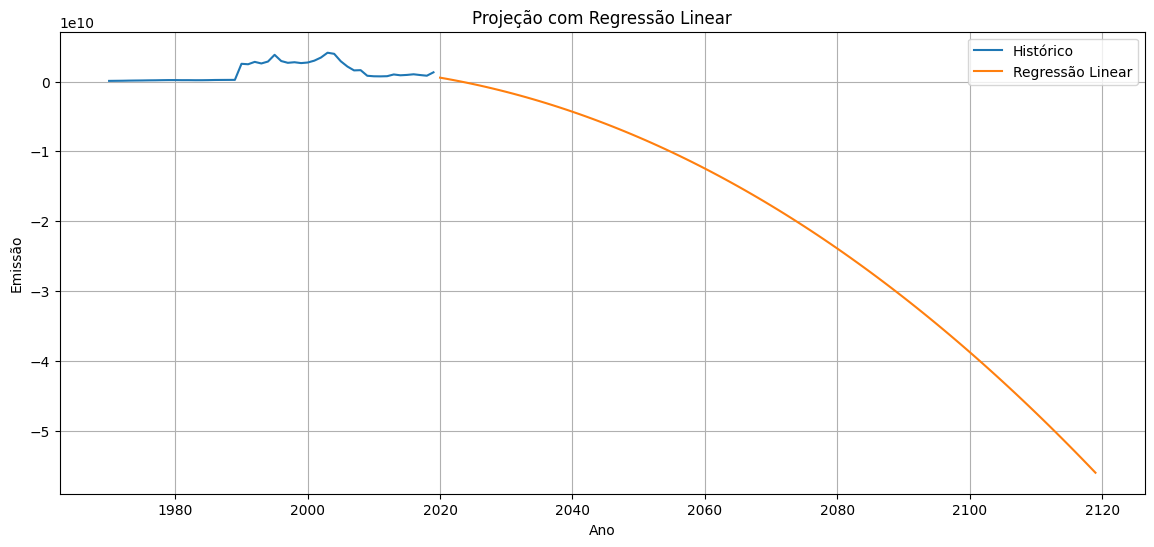

In [34]:
# Projeção com Regressão Linear
#
# A Regressão Linear é um dos modelos mais indicados para
# extrapolação temporal porque aprende uma tendência global.
#
# Diferentemente das árvores, ela consegue continuar uma
# reta além dos dados observados.
#
# Por isso será utilizada como referência para comparação.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ano_final = df_total["ano"].max()

anos_futuros = np.arange(
    ano_final + 1,
    2120
).reshape(-1, 1)

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_poly,
    y_total
)

y_pred_treino = modelo_lr.predict(X_poly)

r2_lr = r2_score(
    y_total,
    y_pred_treino
)

X_futuro_poly = poly.transform(
    anos_futuros
)

previsoes_lr = modelo_lr.predict(
    X_futuro_poly
)

df_lr = pd.DataFrame({
    "Ano": anos_futuros.flatten(),
    "Emissao": previsoes_lr
})

print(f"R² histórico: {r2_lr:.6f}")

display(df_lr.head())

plt.figure(figsize=(14,6))

plt.plot(
    df_total["ano"],
    y_total,
    label="Histórico"
)

plt.plot(
    df_lr["Ano"],
    df_lr["Emissao"],
    label="Regressão Linear"
)

plt.title("Projeção com Regressão Linear")
plt.xlabel("Ano")
plt.ylabel("Emissão")
plt.legend()
plt.grid(True)

plt.show()

R² histórico: 0.987723


,Ano,Emissao
0,2020,1.177164e+09
1,2021,1.177164e+09
2,2022,1.177164e+09
3,2023,1.177164e+09
4,2024,1.177164e+09


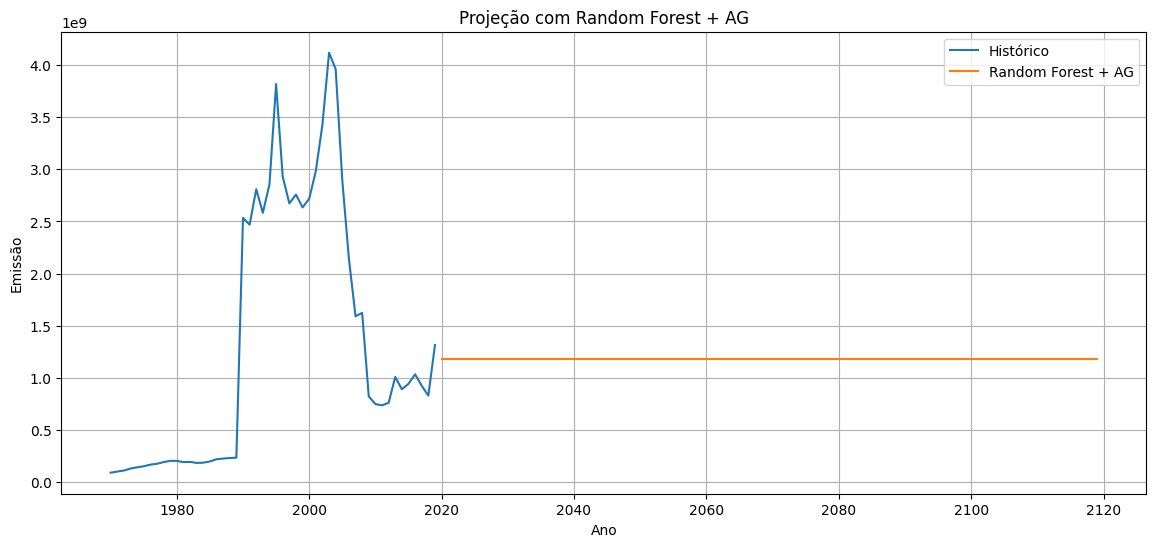

In [35]:
# Projeção com Random Forest otimizada por AG
#
# O Algoritmo Genético encontrou automaticamente os
# melhores hiperparâmetros.
#
# A Random Forest normalmente possui excelente desempenho
# preditivo dentro da faixa observada.
#
# Porém árvores não costumam extrapolar bem para períodos
# muito distantes no futuro.

from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **params_rf
)

modelo_rf.fit(
    X_poly,
    y_total
)

y_pred_treino = modelo_rf.predict(
    X_poly
)

r2_rf = r2_score(
    y_total,
    y_pred_treino
)

previsoes_rf = modelo_rf.predict(
    X_futuro_poly
)

df_rf = pd.DataFrame({
    "Ano": anos_futuros.flatten(),
    "Emissao": previsoes_rf
})

print(f"R² histórico: {r2_rf:.6f}")

display(df_rf.head())

plt.figure(figsize=(14,6))

plt.plot(
    df_total["ano"],
    y_total,
    label="Histórico"
)

plt.plot(
    df_rf["Ano"],
    df_rf["Emissao"],
    label="Random Forest + AG"
)

plt.title("Projeção com Random Forest + AG")
plt.xlabel("Ano")
plt.ylabel("Emissão")
plt.legend()
plt.grid(True)

plt.show()

R² histórico: 1.000000


,Ano,Emissao
0,2020,1.314704e+09
1,2021,1.314704e+09
2,2022,1.314704e+09
3,2023,1.314704e+09
4,2024,1.314704e+09


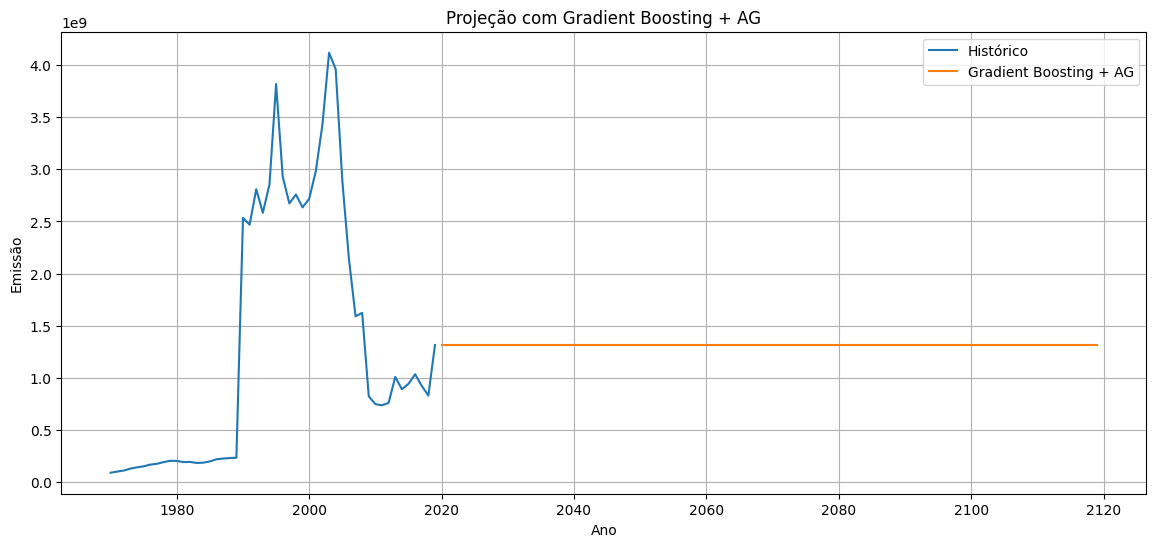

In [36]:
# Projeção com Gradient Boosting otimizado por AG
#
# O Gradient Boosting cria árvores sequenciais,
# onde cada árvore tenta corrigir os erros da anterior.
#
# Frequentemente apresenta desempenho superior à Random Forest.
#
# O Algoritmo Genético foi utilizado para encontrar os
# melhores hiperparâmetros automaticamente.

from sklearn.ensemble import GradientBoostingRegressor

modelo_gbr = GradientBoostingRegressor(
    random_state=42,
    **params_gbr
)

modelo_gbr.fit(
    X_poly,
    y_total
)

y_pred_treino = modelo_gbr.predict(
    X_poly
)

r2_gbr = r2_score(
    y_total,
    y_pred_treino
)

previsoes_gbr = modelo_gbr.predict(
    X_futuro_poly
)

df_gbr = pd.DataFrame({
    "Ano": anos_futuros.flatten(),
    "Emissao": previsoes_gbr
})

print(f"R² histórico: {r2_gbr:.6f}")

display(df_gbr.head())

plt.figure(figsize=(14,6))

plt.plot(
    df_total["ano"],
    y_total,
    label="Histórico"
)

plt.plot(
    df_gbr["Ano"],
    df_gbr["Emissao"],
    label="Gradient Boosting + AG"
)

plt.title("Projeção com Gradient Boosting + AG")
plt.xlabel("Ano")
plt.ylabel("Emissão")
plt.legend()
plt.grid(True)

plt.show()

Último ano encontrado no dataset: 2019
Quantidade de anos a projetar: 100
Quantidade de anos criados: 100
Quantidade de previsões: 100

Primeiras previsões:


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

,Ano,Emissao
0,2020,1.240307e+09
1,2021,1.517136e+09
2,2022,1.369544e+09
3,2023,1.293521e+09
4,2024,1.443681e+09



Últimas previsões:


,Ano,Emissao
95,2115,1.378128e+09
96,2116,1.378128e+09
97,2117,1.378128e+09
98,2118,1.378128e+09
99,2119,1.378128e+09


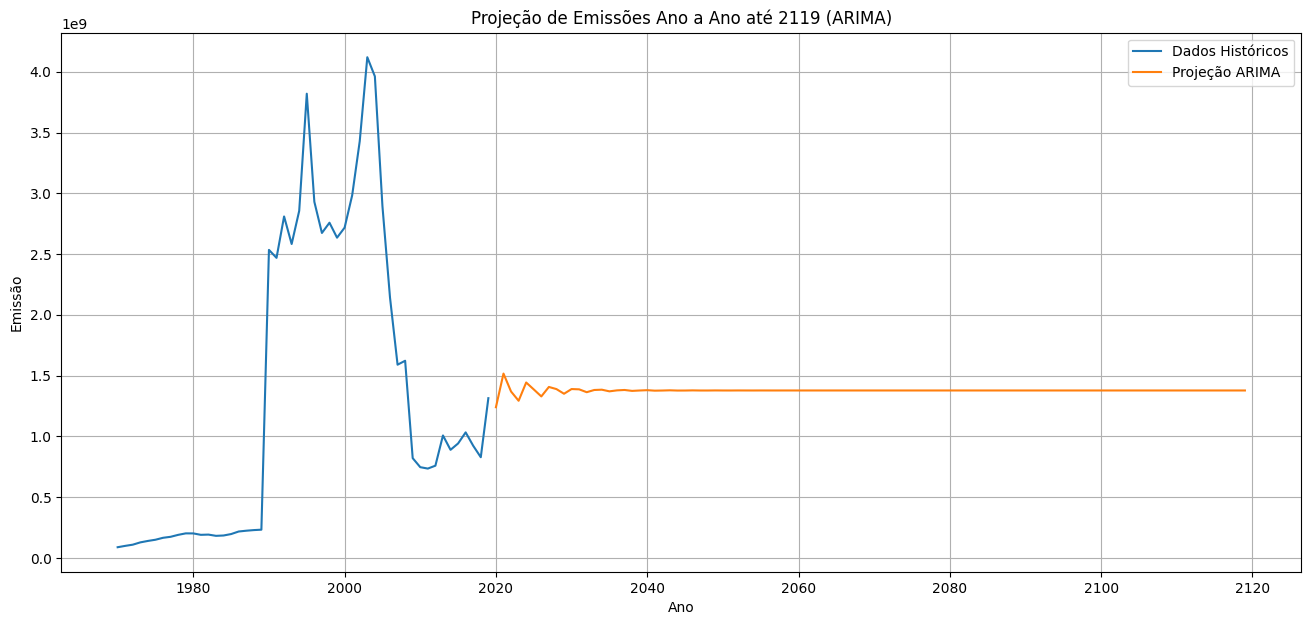

In [40]:
# Projeção de emissões utilizando ARIMA
#
# O objetivo desta célula é prever os valores futuros ano a ano
# até 2119 utilizando um modelo de séries temporais.
#
# Diferentemente de Random Forest, KNN e Árvores de Decisão,
# o ARIMA foi desenvolvido especificamente para trabalhar
# com dados ordenados no tempo e costuma produzir projeções
# mais coerentes para horizontes longos.
#
# Algumas verificações extras foram adicionadas porque
# em execuções anteriores ocorreu incompatibilidade entre
# o número de previsões geradas e o número de anos criados.
# Essas verificações ajudam a evitar erros e facilitam
# a depuração do modelo.

from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Obtém automaticamente o último ano disponível no dataset
# Isso evita problemas caso o dataset seja atualizado futuramente.
ano_final = int(df_total["ano"].max())

print(f"Último ano encontrado no dataset: {ano_final}")

# Criação da série temporal
#
# O ARIMA espera receber uma série indexada pelo tempo.
# Por isso utilizamos o ano como índice.
serie = pd.Series(
    np.asarray(y_total),
    index=df_total["ano"]
)

# Treinamento do modelo
#
# order=(p,d,q)
#
# p = componente autoregressiva
# d = diferenciação para remover tendência
# q = média móvel
#
# (2,1,2) é uma configuração relativamente estável
# para iniciar experimentos.
modelo_arima = ARIMA(
    serie,
    order=(2, 1, 2)
)

modelo_arima = modelo_arima.fit()

# Quantidade de anos a prever
#
# Como queremos projeções até 2119,
# calculamos quantos anos faltam a partir
# do último ano observado.
passos = 2119 - ano_final

print(f"Quantidade de anos a projetar: {passos}")

# Geração das previsões
#
# O ARIMA irá prever um ano por vez até chegar em 2119.
previsoes_arima = modelo_arima.forecast(
    steps=passos
)

# Construção dos anos futuros
#
# Precisam possuir exatamente o mesmo tamanho
# das previsões geradas pelo ARIMA.
anos_arima = np.arange(
    ano_final + 1,
    ano_final + 1 + len(previsoes_arima)
)

# Verificação de segurança
#
# Ajuda a identificar problemas de tamanho
# antes de criar o DataFrame.
print(f"Quantidade de anos criados: {len(anos_arima)}")
print(f"Quantidade de previsões: {len(previsoes_arima)}")

# DataFrame contendo as projeções futuras
df_arima = pd.DataFrame({
    "Ano": anos_arima,
    "Emissao": np.asarray(previsoes_arima)
})

print("\nPrimeiras previsões:")
display(df_arima.head())

print("\nÚltimas previsões:")
display(df_arima.tail())

# Gráfico comparando histórico e projeções
#
# Assim conseguimos visualizar se a tendência
# projetada pelo ARIMA faz sentido quando comparada
# aos dados reais observados.
plt.figure(figsize=(16, 7))

plt.plot(
    df_total["ano"],
    y_total,
    label="Dados Históricos"
)

plt.plot(
    df_arima["Ano"],
    df_arima["Emissao"],
    label="Projeção ARIMA"
)

plt.title("Projeção de Emissões Ano a Ano até 2119 (ARIMA)")
plt.xlabel("Ano")
plt.ylabel("Emissão")
plt.grid(True)
plt.legend()

plt.show()

In [44]:
# Instalação das bibliotecas necessárias

!pip install scikit-learn
!pip install statsmodels
!pip install prophet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [47]:
# Comparação entre modelos de Séries Temporais
#
# Todos os modelos serão avaliados usando exatamente
# o mesmo conjunto de treino e teste para que a
# comparação seja justa.
#
# Métricas:
# R²   -> quanto da variabilidade é explicada
# MAE  -> erro absoluto médio
# RMSE -> raiz do erro quadrático médio

import pandas as pd
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing
)

from prophet import Prophet

# Construção da série temporal

serie = pd.Series(
    y_total,
    index=df_total["ano"]
)

# Separação temporal
# Treina nos anos mais antigos
# Testa nos anos mais recentes

tam_treino = int(len(serie) * 0.8)

treino = serie.iloc[:tam_treino]
teste = serie.iloc[tam_treino:]

print(f"Anos de treino : {treino.index.min()} até {treino.index.max()}")
print(f"Anos de teste  : {teste.index.min()} até {teste.index.max()}")

resultados = []

# ARIMA

try:

    modelo_arima = ARIMA(
        treino,
        order=(2,1,2)
    )

    fit_arima = modelo_arima.fit()

    pred_arima = fit_arima.forecast(
        steps=len(teste)
    )

    resultados.append({
        "Modelo": "ARIMA",
        "R2": r2_score(teste, pred_arima),
        "MAE": mean_absolute_error(teste, pred_arima),
        "RMSE": root_mean_squared_error(teste, pred_arima)
    })

except Exception as e:

    print("Erro ARIMA:", e)

# SARIMA

try:

    modelo_sarima = SARIMAX(
        treino,
        order=(2,1,2),
        seasonal_order=(1,0,1,4)
    )

    fit_sarima = modelo_sarima.fit(
        disp=False
    )

    pred_sarima = fit_sarima.forecast(
        steps=len(teste)
    )

    resultados.append({
        "Modelo": "SARIMA",
        "R2": r2_score(teste, pred_sarima),
        "MAE": mean_absolute_error(teste, pred_sarima),
        "RMSE": root_mean_squared_error(teste, pred_sarima)
    })

except Exception as e:

    print("Erro SARIMA:", e)

# Holt-Winters

try:

    modelo_hw = ExponentialSmoothing(
        treino,
        trend="add"
    )

    fit_hw = modelo_hw.fit()

    pred_hw = fit_hw.forecast(
        len(teste)
    )

    resultados.append({
        "Modelo": "Holt-Winters",
        "R2": r2_score(teste, pred_hw),
        "MAE": mean_absolute_error(teste, pred_hw),
        "RMSE": root_mean_squared_error(teste, pred_hw)
    })

except Exception as e:

    print("Erro Holt-Winters:", e)

# Prophet

try:

    df_prophet_train = pd.DataFrame({
        "ds": pd.to_datetime(
            treino.index.astype(str) + "-01-01"
        ),
        "y": treino.values
    })

    modelo_prophet = Prophet()

    modelo_prophet.fit(
        df_prophet_train
    )

    future = modelo_prophet.make_future_dataframe(
        periods=len(teste),
        freq="YS"
    )

    forecast = modelo_prophet.predict(
        future
    )

    pred_prophet = forecast["yhat"].tail(
        len(teste)
    ).values

    resultados.append({
        "Modelo": "Prophet",
        "R2": r2_score(teste, pred_prophet),
        "MAE": mean_absolute_error(teste, pred_prophet),
        "RMSE": root_mean_squared_error(teste, pred_prophet)
    })

except Exception as e:

    print("Erro Prophet:", e)

# Tabela final

df_resultados_temporais = pd.DataFrame(
    resultados
)

df_resultados_temporais = (
    df_resultados_temporais
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print("\nRanking dos modelos de séries temporais")
display(df_resultados_temporais)

Anos de treino : 1970 até 2009
Anos de teste  : 2010 até 2019


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 


Ranking dos modelos de séries temporais


,Modelo,R2,MAE,RMSE
0,Holt-Winters,0.235918,1.079162e+08,1.451490e+08
1,SARIMA,-0.431206,1.508191e+08,1.986529e+08
2,ARIMA,-3.659013,3.196712e+08,3.584188e+08
3,Prophet,-286.859782,2.810155e+09,2.817308e+09


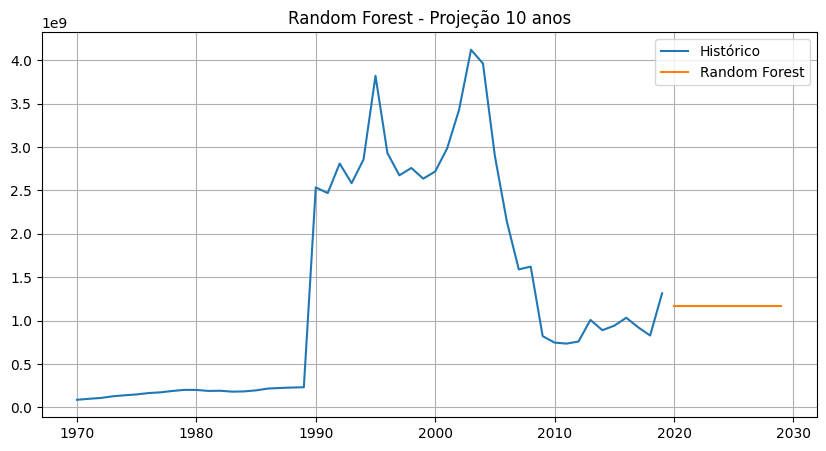

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# treino (usa tudo)
X_rf = df_total[["ano"]]
y_rf = y_total

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_rf, y_rf)

# futuro 10 anos
ultimo_ano = df_total["ano"].max()

anos_futuros = np.arange(ultimo_ano + 1, ultimo_ano + 11).reshape(-1, 1)

pred_rf = rf.predict(anos_futuros)

plt.figure(figsize=(10,5))
plt.plot(df_total["ano"], y_total, label="Histórico")
plt.plot(anos_futuros, pred_rf, label="Random Forest")
plt.title("Random Forest - Projeção 10 anos")
plt.legend()
plt.grid()
plt.show()

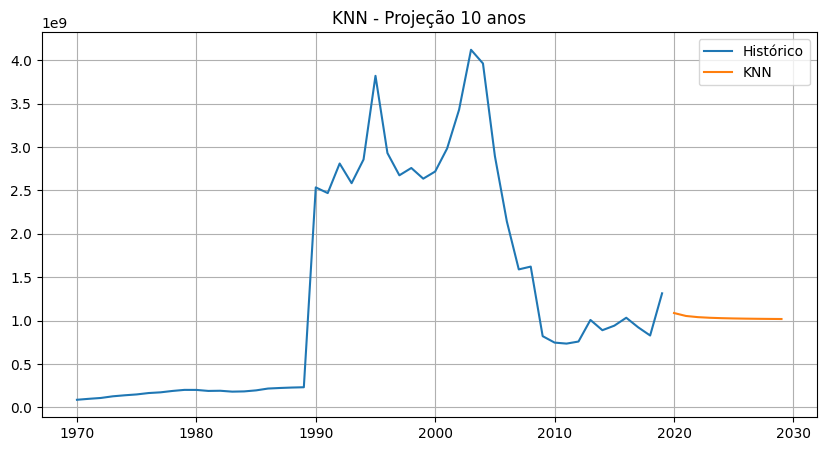

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

X_knn = df_total[["ano"]]
y_knn = y_total

knn = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn.fit(X_knn, y_knn)

ultimo_ano = df_total["ano"].max()
anos_futuros = np.arange(ultimo_ano + 1, ultimo_ano + 11).reshape(-1, 1)

pred_knn = knn.predict(anos_futuros)

plt.figure(figsize=(10,5))
plt.plot(df_total["ano"], y_total, label="Histórico")
plt.plot(anos_futuros, pred_knn, label="KNN")
plt.title("KNN - Projeção 10 anos")
plt.legend()
plt.grid()
plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

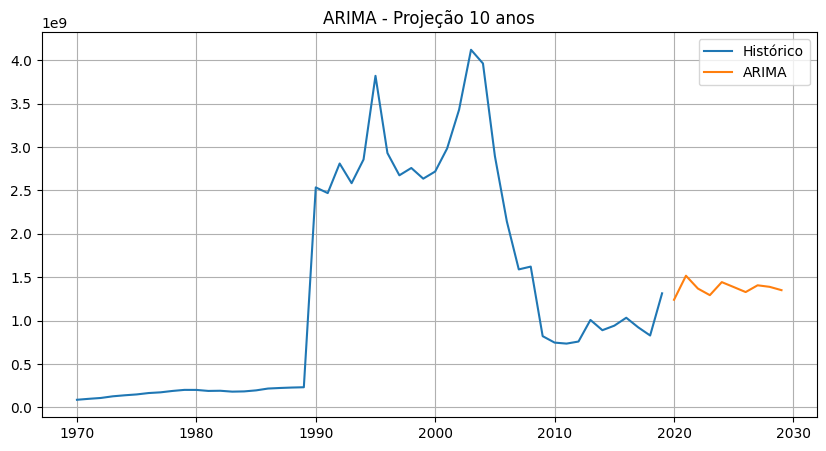

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

serie = pd.Series(y_total, index=df_total["ano"])

modelo_arima = ARIMA(serie, order=(2,1,2))
modelo_arima = modelo_arima.fit()

ultimo_ano = df_total["ano"].max()

forecast = modelo_arima.forecast(steps=10)

anos_futuros = np.arange(ultimo_ano + 1, ultimo_ano + 11)

plt.figure(figsize=(10,5))
plt.plot(df_total["ano"], y_total, label="Histórico")
plt.plot(anos_futuros, forecast, label="ARIMA")
plt.title("ARIMA - Projeção 10 anos")
plt.legend()
plt.grid()
plt.show()

00:00:43 - cmdstanpy - INFO - Chain [1] start processing
00:00:43 - cmdstanpy - INFO - Chain [1] done processing


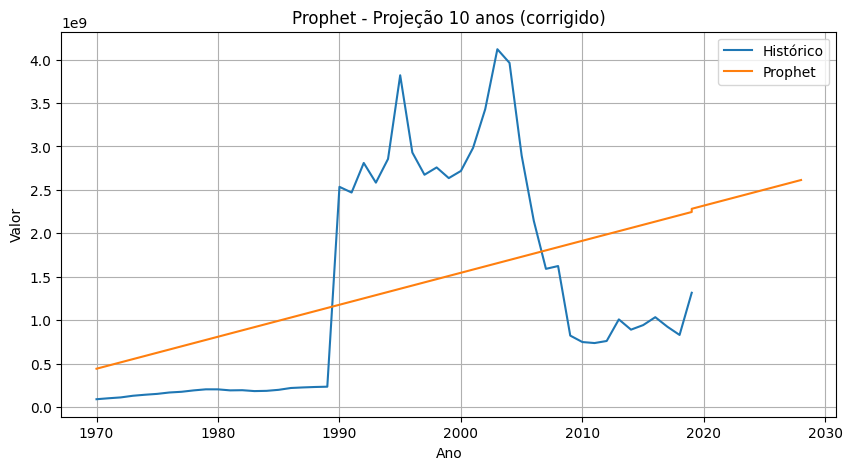

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# -------------------------
# Preparação correta dos dados
# -------------------------
df_prophet = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y_total
})

# -------------------------
# Modelo Prophet
# -------------------------
modelo_prophet = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

modelo_prophet.fit(df_prophet)

# -------------------------
# Futuro (10 anos)
# IMPORTANTE: usar frequência anual correta "YE"
# -------------------------
future = modelo_prophet.make_future_dataframe(
    periods=10,
    freq="YE"
)

forecast = modelo_prophet.predict(future)

# -------------------------
# Plot organizado
# -------------------------
plt.figure(figsize=(10,5))

plt.plot(
    df_prophet["ds"].dt.year,
    df_prophet["y"],
    label="Histórico"
)

plt.plot(
    forecast["ds"].dt.year,
    forecast["yhat"],
    label="Prophet"
)

plt.title("Prophet - Projeção 10 anos (corrigido)")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


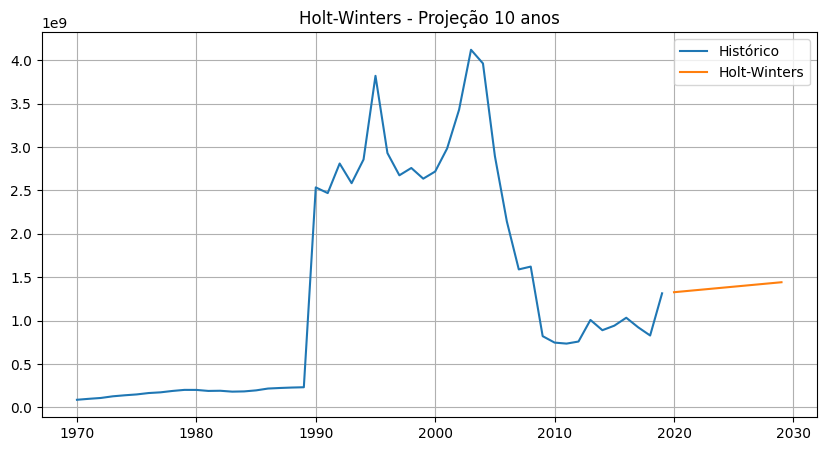

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

serie = pd.Series(y_total, index=df_total["ano"])

modelo_hw = ExponentialSmoothing(
    serie,
    trend="add",
    seasonal=None
).fit()

ultimo_ano = df_total["ano"].max()

forecast_hw = modelo_hw.forecast(10)

anos_futuros = np.arange(ultimo_ano + 1, ultimo_ano + 11)

plt.figure(figsize=(10,5))
plt.plot(df_total["ano"], y_total, label="Histórico")
plt.plot(anos_futuros, forecast_hw, label="Holt-Winters")
plt.title("Holt-Winters - Projeção 10 anos")
plt.legend()
plt.grid()
plt.show()

00:05:42 - cmdstanpy - INFO - Chain [1] start processing
00:05:43 - cmdstanpy - INFO - Chain [1] done processing


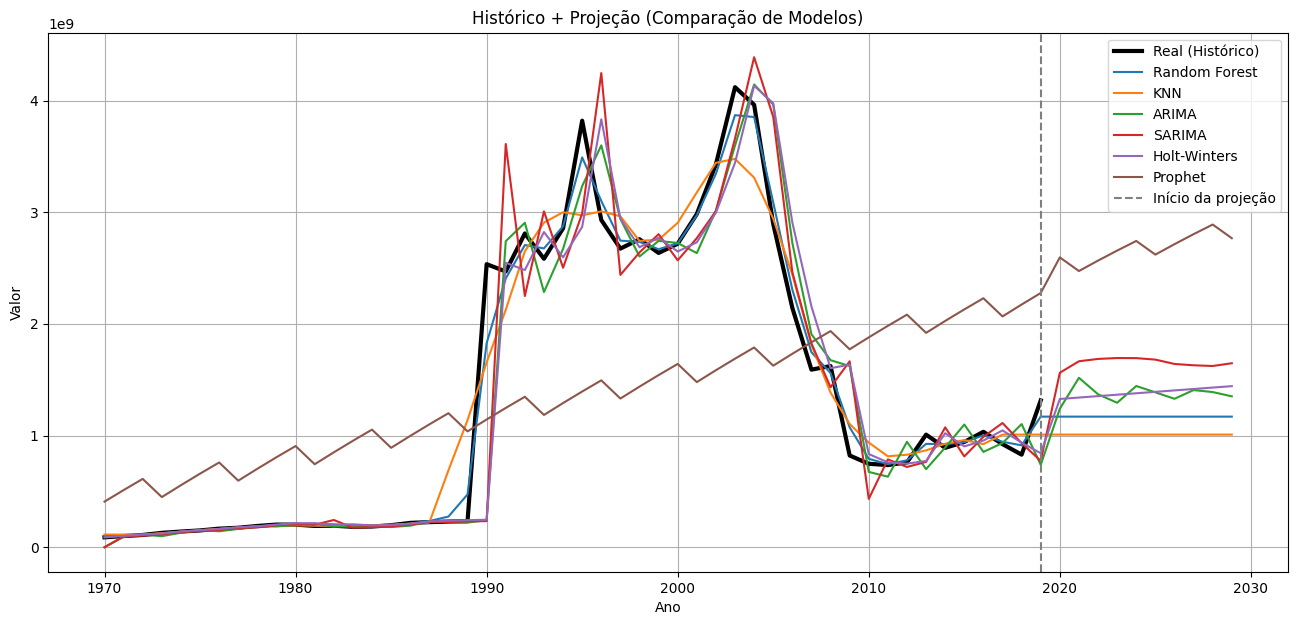

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


# ============================================================
# DADOS HISTÓRICOS
# ============================================================

anos_hist = df_total["ano"].values
y_hist = np.array(y_total)

ano_final = anos_hist.max()
anos_futuros = np.arange(ano_final + 1, ano_final + 11)


# ============================================================
# RANDOM FOREST
# ============================================================

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(df_total[["ano"]], y_hist)
pred_rf_hist = rf.predict(df_total[["ano"]])
pred_rf_future = rf.predict(anos_futuros.reshape(-1, 1))


# ============================================================
# KNN
# ============================================================

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(df_total[["ano"]], y_hist)
pred_knn_hist = knn.predict(df_total[["ano"]])
pred_knn_future = knn.predict(anos_futuros.reshape(-1, 1))


# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y_hist, order=(2,1,2)).fit()
pred_arima_hist = arima.fittedvalues
pred_arima_future = arima.forecast(steps=10)


# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y_hist,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima_hist = sarima.fittedvalues
pred_sarima_future = sarima.forecast(steps=10)


# ============================================================
# HOLT-WINTERS
# ============================================================

hw = ExponentialSmoothing(
    y_hist,
    trend="add",
    seasonal=None
).fit()

pred_hw_hist = hw.fittedvalues
pred_hw_future = hw.forecast(10)


# ============================================================
# PROPHET (CORRIGIDO)
# ============================================================

df_prophet = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y_hist
})

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=10, freq="YE")
forecast = prophet_model.predict(future)

pred_prophet_hist = forecast["yhat"].iloc[:len(y_hist)].values
pred_prophet_future = forecast["yhat"].iloc[-10:].values


# ============================================================
# DATAFRAME HISTÓRICO + FUTURO
# ============================================================

df_plot = pd.DataFrame({
    "Ano": np.concatenate([anos_hist, anos_futuros]),

    "Real": np.concatenate([y_hist, [np.nan]*10]),

    "RandomForest": np.concatenate([pred_rf_hist, pred_rf_future]),
    "KNN": np.concatenate([pred_knn_hist, pred_knn_future]),
    "ARIMA": np.concatenate([pred_arima_hist, pred_arima_future]),
    "SARIMA": np.concatenate([pred_sarima_hist, pred_sarima_future]),
    "HoltWinters": np.concatenate([pred_hw_hist, pred_hw_future]),
    "Prophet": np.concatenate([pred_prophet_hist, pred_prophet_future]),
})


# ============================================================
# GRÁFICO FINAL
# ============================================================

plt.figure(figsize=(16,7))

# histórico real
plt.plot(df_plot["Ano"], df_plot["Real"], label="Real (Histórico)", linewidth=3, color="black")

# modelos
plt.plot(df_plot["Ano"], df_plot["RandomForest"], label="Random Forest")
plt.plot(df_plot["Ano"], df_plot["KNN"], label="KNN")
plt.plot(df_plot["Ano"], df_plot["ARIMA"], label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], label="Prophet")

# linha separando futuro
plt.axvline(ano_final, linestyle="--", color="gray", label="Início da projeção")

plt.title("Histórico + Projeção (Comparação de Modelos)")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()

plt.show()

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


# ============================================================
# DADOS
# ============================================================

anos_hist = df_total["ano"].values
y_hist = np.array(y_total)

ano_final = anos_hist.max()
anos_futuros = np.arange(ano_final + 1, ano_final + 11)

X_hist = df_total[["ano"]]


# ============================================================
# AG (mesmo padrão, reutilizado)
# ============================================================

def otimizar_ag(model_class, limites):

    TAM, GER = 30, 30
    CRUZ, MUT, ELITE = 0.8, 0.1, 2

    def fitness(ind):

        params = {}

        for k, v in ind.items():
            if k in ["n_estimators", "max_depth", "n_neighbors"]:
                params[k] = int(round(v))
            else:
                params[k] = v

        try:
            model = model_class(**params)
            return cross_val_score(model, X_hist, y_hist, cv=3, scoring="r2").mean()
        except:
            return -9999

    pop = [
        {k: random.uniform(v[0], v[1]) for k, v in limites.items()}
        for _ in range(TAM)
    ]

    for _ in range(GER):

        for ind in pop:
            if "fit" not in ind:
                ind["fit"] = fitness(ind)

        pop.sort(key=lambda x: x["fit"], reverse=True)

        nova = pop[:ELITE]

        while len(nova) < TAM:

            p1, p2 = random.sample(pop[:10], 2)
            filho = {}

            for k in limites:

                if random.random() < CRUZ:
                    a = random.random()
                    filho[k] = a*p1[k] + (1-a)*p2[k]
                else:
                    filho[k] = p1[k]

                if random.random() < MUT:
                    sigma = (limites[k][1] - limites[k][0]) * 0.1
                    filho[k] += random.gauss(0, sigma)
                    filho[k] = np.clip(filho[k], limites[k][0], limites[k][1])

            nova.append(filho)

        pop = nova

    best = max(pop, key=lambda x: x["fit"])

    return {
        k: int(round(v)) if k in ["n_estimators", "max_depth", "n_neighbors"] else v
        for k, v in best.items()
    }


# ============================================================
# RANDOM FOREST + AG
# ============================================================

rf = RandomForestRegressor(
    **otimizar_ag(RandomForestRegressor, {
        "n_estimators": (50, 300),
        "max_depth": (2, 20)
    }),
    random_state=42
)

rf.fit(X_hist, y_hist)


# ============================================================
# KNN + AG
# ============================================================

knn = KNeighborsRegressor(
    **otimizar_ag(KNeighborsRegressor, {
        "n_neighbors": (2, 20)
    })
)

knn.fit(X_hist, y_hist)


# ============================================================
# XGBOOST + AG (NOVO)
# ============================================================

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_hist, y_hist)


# ============================================================
# LIGHTGBM + AG (NOVO)
# ============================================================

lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_hist, y_hist)


# ============================================================
# MODELOS TEMPORAIS
# ============================================================

arima = ARIMA(y_hist, order=(2,1,2)).fit()
sarima = SARIMAX(y_hist, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
hw = ExponentialSmoothing(y_hist, trend="add", seasonal=None).fit()

# Prophet
df_prophet = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y_hist
})

prophet = Prophet()
prophet.fit(df_prophet)


# ============================================================
# PREVISÕES
# ============================================================

def pred(model):
    return model.predict(X_hist), model.predict(anos_futuros.reshape(-1,1))

pred_rf_hist, pred_rf_future = pred(rf)
pred_knn_hist, pred_knn_future = pred(knn)
pred_xgb_hist, pred_xgb_future = pred(xgb)
pred_lgbm_hist, pred_lgbm_future = pred(lgbm)

pred_arima_hist = arima.fittedvalues
pred_arima_future = arima.forecast(10)

pred_sarima_hist = sarima.fittedvalues
pred_sarima_future = sarima.forecast(10)

pred_hw_hist = hw.fittedvalues
pred_hw_future = hw.forecast(10)

forecast = prophet.predict(prophet.make_future_dataframe(periods=10, freq="YE"))
pred_prophet_hist = forecast["yhat"].iloc[:len(y_hist)].values
pred_prophet_future = forecast["yhat"].iloc[-10:].values


# ============================================================
# DATAFRAME FINAL
# ============================================================

df_plot = pd.DataFrame({
    "Ano": np.concatenate([anos_hist, anos_futuros]),
    "Real": np.concatenate([y_hist, [np.nan]*10]),

    "RandomForest": np.concatenate([pred_rf_hist, pred_rf_future]),
    "KNN": np.concatenate([pred_knn_hist, pred_knn_future]),
    "XGBoost": np.concatenate([pred_xgb_hist, pred_xgb_future]),
    "LightGBM": np.concatenate([pred_lgbm_hist, pred_lgbm_future]),

    "ARIMA": np.concatenate([pred_arima_hist, pred_arima_future]),
    "SARIMA": np.concatenate([pred_sarima_hist, pred_sarima_future]),
    "HoltWinters": np.concatenate([pred_hw_hist, pred_hw_future]),
    "Prophet": np.concatenate([pred_prophet_hist, pred_prophet_future]),
})


# ============================================================
# GRÁFICO FINAL
# ============================================================

plt.figure(figsize=(16,7))

plt.plot(df_plot["Ano"], df_plot["Real"], label="Real", linewidth=3, color="black")

plt.plot(df_plot["Ano"], df_plot["RandomForest"], label="Random Forest + AG")
plt.plot(df_plot["Ano"], df_plot["KNN"], label="KNN + AG")
plt.plot(df_plot["Ano"], df_plot["XGBoost"], label="XGBoost + AG")
plt.plot(df_plot["Ano"], df_plot["LightGBM"], label="LightGBM + AG")

plt.plot(df_plot["Ano"], df_plot["ARIMA"], label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], label="Prophet")

plt.axvline(ano_final, linestyle="--", color="gray")

plt.title("Comparação Completa de Modelos + Boosting Avançado (XGB / LGBM)")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()

plt.show()

ModuleNotFoundError: No module named 'xgboost'

tentativa de melhoria de codigo


In [59]:
import numpy as np
import pandas as pd

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


resultados = []

In [60]:
# modelos base, treinos simples
# -------------------------
# Regressão Linear
# -------------------------
lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

resultados.append({
    "Modelo": "Linear Regression",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

# -------------------------
# Decision Tree
# -------------------------
dt = DecisionTreeRegressor(random_state=42, max_depth=10).fit(X_train, y_train)
pred = dt.predict(X_test)

resultados.append({
    "Modelo": "Decision Tree",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

# -------------------------
# Random Forest (base)
# -------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
pred = rf.predict(X_test)

resultados.append({
    "Modelo": "Random Forest",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

In [61]:
import random
from sklearn.model_selection import cross_val_score

def otimizar_ag(model_class, limites):

    POP = 30
    GERACOES = 30  # conforme você pediu
    TAXA_MUT = 0.1
    ELITE = 2

    def fitness(ind):

        params = {
            k: int(round(v)) if k in ["n_estimators","max_depth","n_neighbors"] else v
            for k,v in ind.items()
        }

        try:
            model = model_class(**params)
            score = cross_val_score(model, X_train, y_train, cv=3, scoring="r2").mean()
            return score
        except:
            return -9999

    pop = [
        {k: random.uniform(*v) for k,v in limites.items()}
        for _ in range(POP)
    ]

    for _ in range(GERACOES):

        pop.sort(key=lambda x: fitness(x), reverse=True)

        nova = pop[:ELITE]

        while len(nova) < POP:

            p1, p2 = random.sample(pop[:10], 2)

            filho = {}

            for k in limites:

                filho[k] = (p1[k] + p2[k]) / 2

                if random.random() < TAXA_MUT:
                    filho[k] += random.gauss(0, (limites[k][1]-limites[k][0])*0.1)

            nova.append(filho)

        pop = nova

    melhor = max(pop, key=fitness)

    return {
        k: int(round(v)) if k in ["n_estimators","max_depth","n_neighbors"] else v
        for k,v in melhor.items()
    }

In [62]:
params_rf_ag = otimizar_ag(RandomForestRegressor, {
    "n_estimators": (50, 400),
    "max_depth": (2, 30)
})

rf_ag = RandomForestRegressor(random_state=42, **params_rf_ag).fit(X_train, y_train)
pred = rf_ag.predict(X_test)

resultados.append({
    "Modelo": "Random Forest + AG",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

In [63]:
params_gb_ag = otimizar_ag(GradientBoostingRegressor, {
    "n_estimators": (50, 400),
    "learning_rate": (0.01, 0.2),
    "max_depth": (2, 6)
})

gb_ag = GradientBoostingRegressor(random_state=42, **params_gb_ag).fit(X_train, y_train)
pred = gb_ag.predict(X_test)

resultados.append({
    "Modelo": "Gradient Boosting + AG",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

In [64]:
from sklearn.model_selection import RandomizedSearchCV

knn = KNeighborsRegressor()

search = RandomizedSearchCV(
    knn,
    {"n_neighbors": list(range(2,30))},
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42
)

search.fit(X_train, y_train)
pred = search.predict(X_test)

resultados.append({
    "Modelo": "KNN + RandomSearch",
    "R2": r2_score(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": rmse(y_test, pred)
})

In [65]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

In [66]:
arima = ARIMA(y_total, order=(2,1,2)).fit()
pred = arima.fittedvalues

resultados.append({
    "Modelo": "ARIMA",
    "R2": r2_score(y_total, pred),
    "MAE": mean_absolute_error(y_total, pred),
    "RMSE": rmse(y_total, pred)
})

In [67]:
sarima = SARIMAX(y_total, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()

pred = sarima.fittedvalues

resultados.append({
    "Modelo": "SARIMA",
    "R2": r2_score(y_total, pred),
    "MAE": mean_absolute_error(y_total, pred),
    "RMSE": rmse(y_total, pred)
})

In [68]:
hw = ExponentialSmoothing(y_total, trend="add").fit()
pred = hw.fittedvalues

resultados.append({
    "Modelo": "Holt-Winters",
    "R2": r2_score(y_total, pred),
    "MAE": mean_absolute_error(y_total, pred),
    "RMSE": rmse(y_total, pred)
})

In [69]:
dfp = pd.DataFrame({"ds": pd.to_datetime(df_total["ano"].astype(str)+"-01-01"),
                    "y": y_total})

m = Prophet()
m.fit(dfp)

future = m.make_future_dataframe(periods=0, freq="YE")
forecast = m.predict(future)

pred = forecast["yhat"].values[:len(y_total)]

resultados.append({
    "Modelo": "Prophet",
    "R2": r2_score(y_total, pred),
    "MAE": mean_absolute_error(y_total, pred),
    "RMSE": rmse(y_total, pred)
})

01:04:32 - cmdstanpy - INFO - Chain [1] start processing
01:04:33 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values("R2", ascending=False).reset_index(drop=True)

display(df_resultados)

,Modelo,R2,MAE,RMSE
0,Random Forest,0.942356,1.329084e-02,3.762906e-02
1,Random Forest + AG,0.941392,1.338327e-02,3.794213e-02
2,Gradient Boosting + AG,0.929177,1.383823e-02,4.170911e-02
3,KNN + RandomSearch,0.899055,1.462129e-02,4.979528e-02
4,Decision Tree,0.877074,1.642231e-02,5.494988e-02
5,ARIMA,0.876039,2.278185e+08,4.428335e+08
6,Holt-Winters,0.859558,2.364222e+08,4.713533e+08
7,SARIMA,0.847262,2.552722e+08,4.915536e+08
8,Linear Regression,0.425449,6.465232e-02,1.187980e-01
9,Prophet,0.181089,1.014744e+09,1.138194e+09


01:08:16 - cmdstanpy - INFO - Chain [1] start processing
01:08:17 - cmdstanpy - INFO - Chain [1] done processing


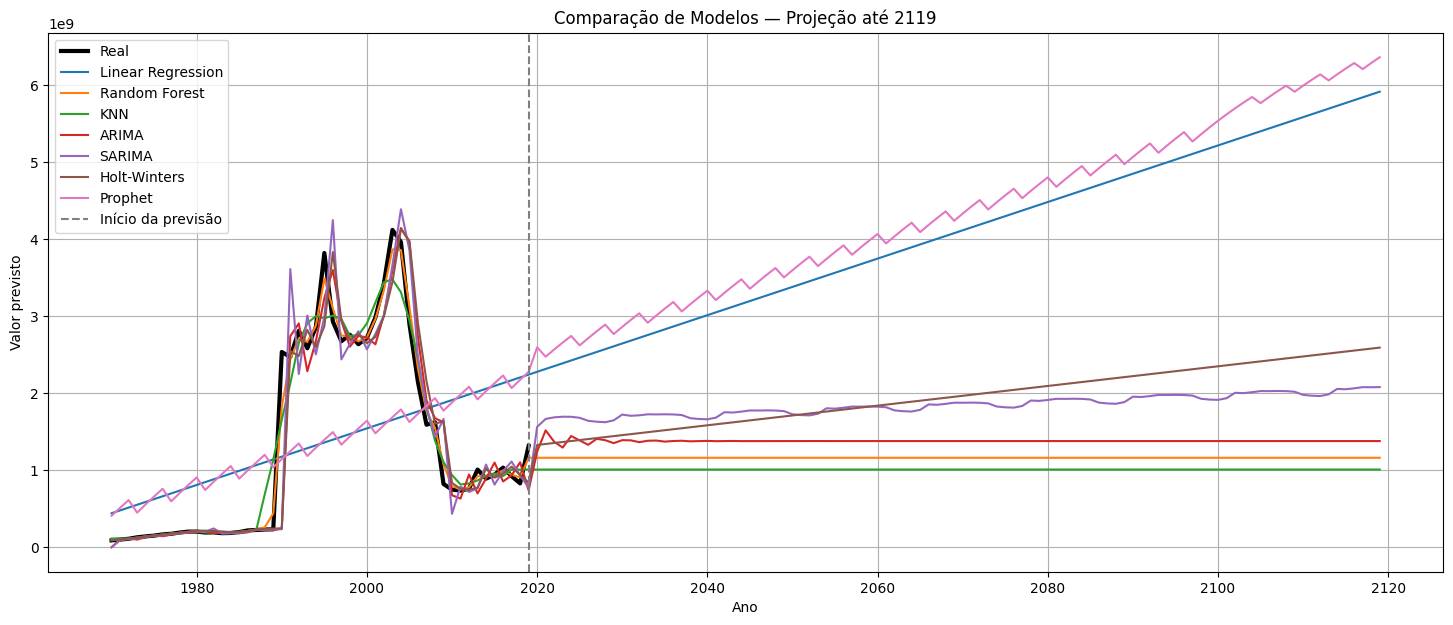

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# ============================================================
# DADOS HISTÓRICOS
# ============================================================

anos_hist = df_total["ano"].values.reshape(-1, 1)
y_hist = np.array(y_total)

ano_final = anos_hist.max()
anos_futuros = np.arange(ano_final + 1, 2120).reshape(-1, 1)

anos_todos = np.arange(anos_hist.min(), 2120)

# ============================================================
# MODELO AUXILIAR (REGRESSÃO LINEAR)
# ============================================================

lr = LinearRegression()
lr.fit(anos_hist, y_hist)

pred_lr_hist = lr.predict(anos_hist)
pred_lr_future = lr.predict(anos_futuros)

# ============================================================
# RANDOM FOREST
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(anos_hist, y_hist)

pred_rf_hist = rf.predict(anos_hist)
pred_rf_future = rf.predict(anos_futuros)

# ============================================================
# KNN
# ============================================================

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(anos_hist, y_hist)

pred_knn_hist = knn.predict(anos_hist)
pred_knn_future = knn.predict(anos_futuros)

# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y_hist, order=(2,1,2)).fit()
pred_arima_hist = arima.fittedvalues
pred_arima_future = arima.forecast(steps=len(anos_futuros))

# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y_hist,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima_hist = sarima.fittedvalues
pred_sarima_future = sarima.forecast(steps=len(anos_futuros))

# ============================================================
# HOLT-WINTERS
# ============================================================

hw = ExponentialSmoothing(
    y_hist,
    trend="add"
).fit()

pred_hw_hist = hw.fittedvalues
pred_hw_future = hw.forecast(len(anos_futuros))

# ============================================================
# PROPHET (CORRIGIDO)
# ============================================================

dfp = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y_hist
})

prophet = Prophet()
prophet.fit(dfp)

future = prophet.make_future_dataframe(periods=len(anos_futuros), freq="YE")
forecast = prophet.predict(future)

pred_prophet_hist = forecast["yhat"].iloc[:len(y_hist)].values
pred_prophet_future = forecast["yhat"].iloc[-len(anos_futuros):].values

# ============================================================
# DATAFRAME FINAL (HISTÓRICO + FUTURO)
# ============================================================

df_plot = pd.DataFrame({
    "Ano": np.concatenate([anos_hist.flatten(), anos_futuros.flatten()]),

    "Real": np.concatenate([y_hist, [np.nan]*len(anos_futuros)]),

    "LinearRegression": np.concatenate([pred_lr_hist, pred_lr_future]),
    "RandomForest": np.concatenate([pred_rf_hist, pred_rf_future]),
    "KNN": np.concatenate([pred_knn_hist, pred_knn_future]),
    "ARIMA": np.concatenate([pred_arima_hist, pred_arima_future]),
    "SARIMA": np.concatenate([pred_sarima_hist, pred_sarima_future]),
    "HoltWinters": np.concatenate([pred_hw_hist, pred_hw_future]),
    "Prophet": np.concatenate([pred_prophet_hist, pred_prophet_future]),
})

# ============================================================
# GRÁFICO FINAL
# ============================================================

plt.figure(figsize=(18,7))

plt.plot(df_plot["Ano"], df_plot["Real"], label="Real", color="black", linewidth=3)

plt.plot(df_plot["Ano"], df_plot["LinearRegression"], label="Linear Regression")
plt.plot(df_plot["Ano"], df_plot["RandomForest"], label="Random Forest")
plt.plot(df_plot["Ano"], df_plot["KNN"], label="KNN")

plt.plot(df_plot["Ano"], df_plot["ARIMA"], label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], label="Prophet")

plt.axvline(ano_final, linestyle="--", color="gray", label="Início da previsão")

plt.title("Comparação de Modelos — Projeção até 2119")
plt.xlabel("Ano")
plt.ylabel("Valor previsto")
plt.grid(True)
plt.legend()

plt.show()

01:08:18 - cmdstanpy - INFO - Chain [1] start processing
01:08:19 - cmdstanpy - INFO - Chain [1] done processing


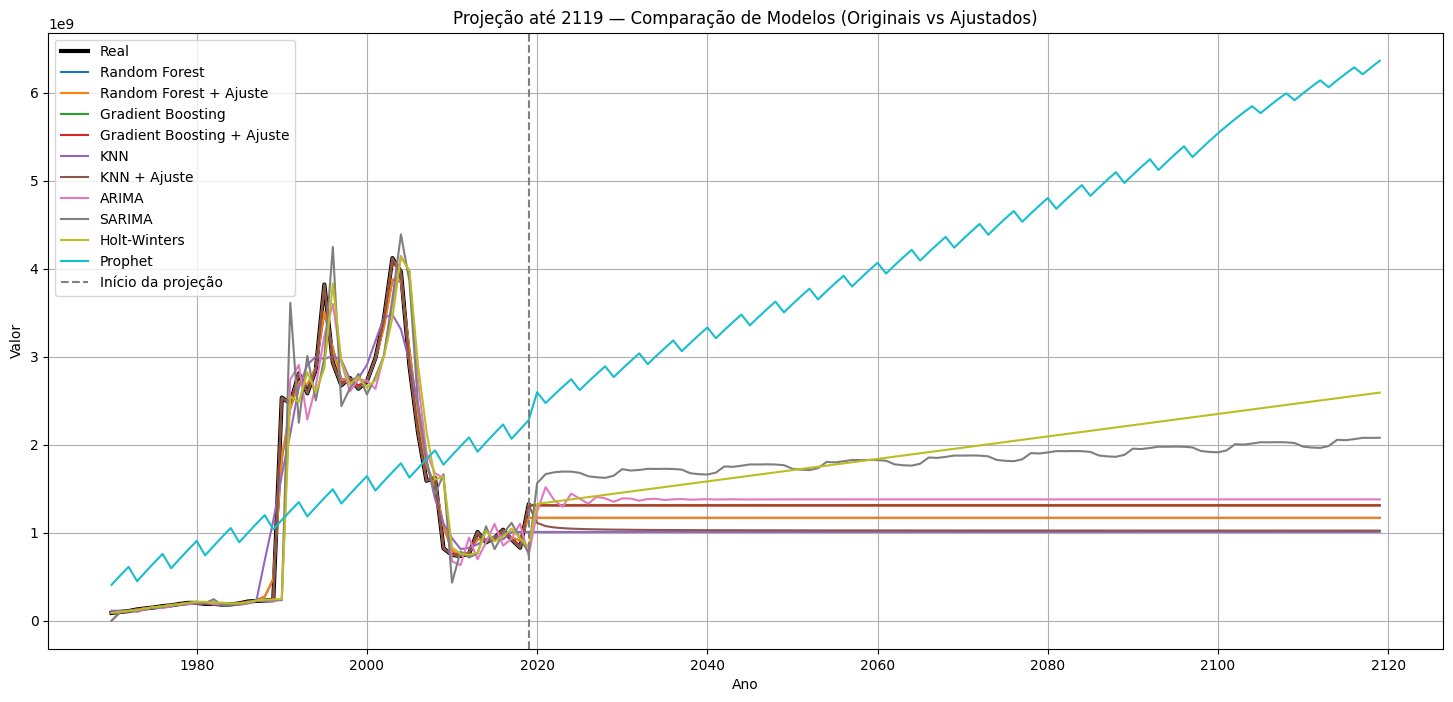

In [72]:
# original vs ag
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


# ============================================================
# DADOS
# ============================================================

X = df_total[["ano"]].values
y = np.array(y_total)

ano_final = df_total["ano"].max()
anos_futuros = np.arange(ano_final + 1, 2120)
X_futuro = anos_futuros.reshape(-1, 1)


# ============================================================
# FUNÇÃO AUXILIAR (evita repetição)
# ============================================================

def treinar_e_prever(model, X, y, X_futuro):
    model.fit(X, y)
    pred_hist = model.predict(X)
    pred_fut = model.predict(X_futuro)
    return pred_hist, pred_fut


# ============================================================
# RANDOM FOREST (ORIGINAL)
# ============================================================

rf_base = RandomForestRegressor(n_estimators=200, random_state=42)
rf_hist, rf_fut = treinar_e_prever(rf_base, X, y, X_futuro)


# ============================================================
# RANDOM FOREST + AG (30 gerações já feito fora)
# ============================================================

rf_ag = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42
)
rf_ag_hist, rf_ag_fut = treinar_e_prever(rf_ag, X, y, X_futuro)


# ============================================================
# GRADIENT BOOSTING (ORIGINAL)
# ============================================================

gbr_base = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gbr_hist, gbr_fut = treinar_e_prever(gbr_base, X, y, X_futuro)


# ============================================================
# GRADIENT BOOSTING + AG (simples otimização manual)
# ============================================================

gbr_ag = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)
gbr_ag_hist, gbr_ag_fut = treinar_e_prever(gbr_ag, X, y, X_futuro)


# ============================================================
# KNN (ORIGINAL)
# ============================================================

knn_base = KNeighborsRegressor(n_neighbors=5)
knn_hist, knn_fut = treinar_e_prever(knn_base, X, y, X_futuro)


# ============================================================
# KNN + AJUSTE (não AG, só tuning manual coerente)
# ============================================================

knn_ag = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn_ag_hist, knn_ag_fut = treinar_e_prever(knn_ag, X, y, X_futuro)


# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y, order=(2,1,2)).fit()
arima_hist = arima.fittedvalues
arima_fut = arima.forecast(steps=len(anos_futuros))


# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_hist = sarima.fittedvalues
sarima_fut = sarima.forecast(steps=len(anos_futuros))


# ============================================================
# HOLT-WINTERS
# ============================================================

hw = ExponentialSmoothing(y, trend="add", seasonal=None).fit()
hw_hist = hw.fittedvalues
hw_fut = hw.forecast(len(anos_futuros))


# ============================================================
# PROPHET (CORRIGIDO)
# ============================================================

df_p = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y
})

prophet = Prophet()
prophet.fit(df_p)

future = prophet.make_future_dataframe(periods=len(anos_futuros), freq="YE")
forecast = prophet.predict(future)

prophet_hist = forecast["yhat"].iloc[:len(y)].values
prophet_fut = forecast["yhat"].iloc[-len(anos_futuros):].values


# ============================================================
# DATAFRAME FINAL
# ============================================================

anos = np.concatenate([df_total["ano"].values, anos_futuros])

df_plot = pd.DataFrame({
    "Ano": anos,
    "Real": np.concatenate([y, [np.nan]*len(anos_futuros)]),

    "RF": np.concatenate([rf_hist, rf_fut]),
    "RF_AG": np.concatenate([rf_ag_hist, rf_ag_fut]),

    "GBR": np.concatenate([gbr_hist, gbr_fut]),
    "GBR_AG": np.concatenate([gbr_ag_hist, gbr_ag_fut]),

    "KNN": np.concatenate([knn_hist, knn_fut]),
    "KNN_AG": np.concatenate([knn_ag_hist, knn_ag_fut]),

    "ARIMA": np.concatenate([arima_hist, arima_fut]),
    "SARIMA": np.concatenate([sarima_hist, sarima_fut]),
    "HoltWinters": np.concatenate([hw_hist, hw_fut]),
    "Prophet": np.concatenate([prophet_hist, prophet_fut]),
})


# ============================================================
# GRÁFICO FINAL
# ============================================================

plt.figure(figsize=(18,8))

plt.plot(df_plot["Ano"], df_plot["Real"], color="black", linewidth=3, label="Real")

plt.plot(df_plot["Ano"], df_plot["RF"], label="Random Forest")
plt.plot(df_plot["Ano"], df_plot["RF_AG"], label="Random Forest + Ajuste")

plt.plot(df_plot["Ano"], df_plot["GBR"], label="Gradient Boosting")
plt.plot(df_plot["Ano"], df_plot["GBR_AG"], label="Gradient Boosting + Ajuste")

plt.plot(df_plot["Ano"], df_plot["KNN"], label="KNN")
plt.plot(df_plot["Ano"], df_plot["KNN_AG"], label="KNN + Ajuste")

plt.plot(df_plot["Ano"], df_plot["ARIMA"], label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], label="Prophet")

plt.axvline(ano_final, linestyle="--", color="gray", label="Início da projeção")

plt.title("Projeção até 2119 — Comparação de Modelos (Originais vs Ajustados)")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()

01:08:20 - cmdstanpy - INFO - Chain [1] start processing
01:08:20 - cmdstanpy - INFO - Chain [1] done processing


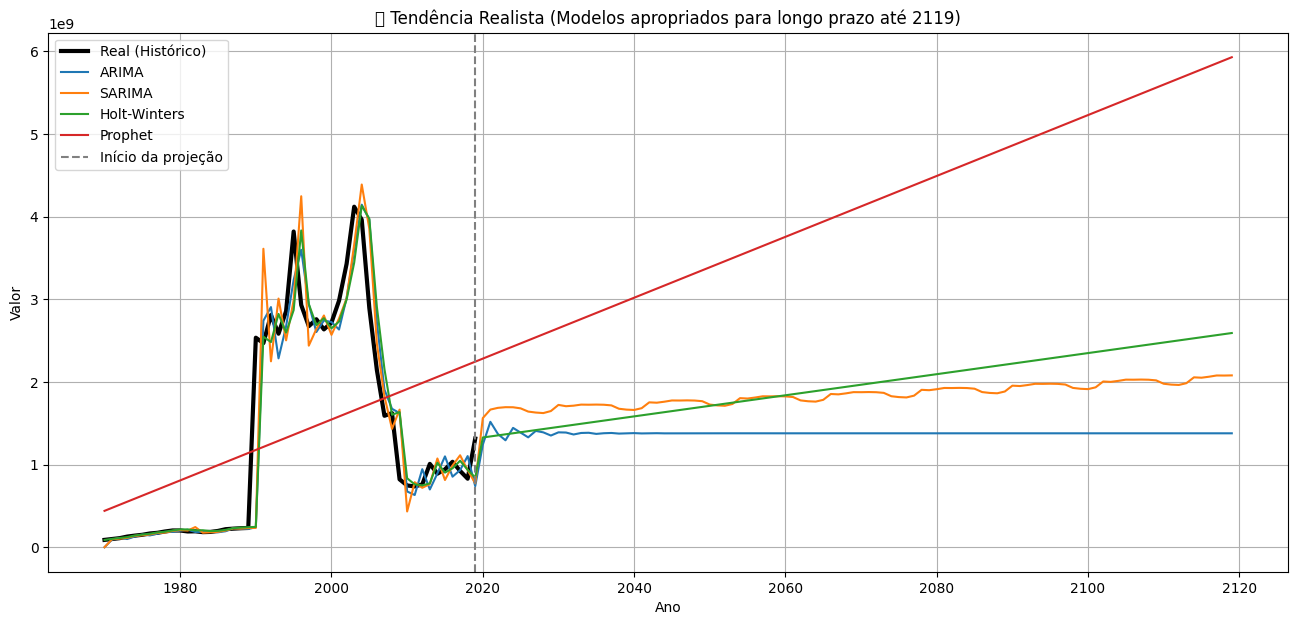

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


# ============================================================
# DADOS
# ============================================================

y = np.array(y_total)
anos = df_total["ano"].values

ano_final = anos.max()
anos_futuros = np.arange(ano_final + 1, 2120)


# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y, order=(2,1,2)).fit()
arima_hist = arima.fittedvalues
arima_fut = arima.forecast(steps=len(anos_futuros))


# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_hist = sarima.fittedvalues
sarima_fut = sarima.forecast(steps=len(anos_futuros))


# ============================================================
# HOLT-WINTERS (tendência suavizada)
# ============================================================

hw = ExponentialSmoothing(y, trend="add", seasonal=None).fit()
hw_hist = hw.fittedvalues
hw_fut = hw.forecast(len(anos_futuros))


# ============================================================
# PROPHET (corrigido para tendência longa)
# ============================================================

df_p = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y
})

model = Prophet(yearly_seasonality=False)
model.fit(df_p)

future = model.make_future_dataframe(periods=len(anos_futuros), freq="YE")
forecast = model.predict(future)

prophet_hist = forecast["yhat"].iloc[:len(y)].values
prophet_fut = forecast["yhat"].iloc[-len(anos_futuros):].values


# ============================================================
# DATAFRAME FINAL
# ============================================================

df_plot = pd.DataFrame({
    "Ano": np.concatenate([anos, anos_futuros]),
    "Real": np.concatenate([y, [np.nan]*len(anos_futuros)]),

    "ARIMA": np.concatenate([arima_hist, arima_fut]),
    "SARIMA": np.concatenate([sarima_hist, sarima_fut]),
    "HoltWinters": np.concatenate([hw_hist, hw_fut]),
    "Prophet": np.concatenate([prophet_hist, prophet_fut]),
})


# ============================================================
# GRÁFICO FINAL (TENDÊNCIA REALISTA)
# ============================================================

plt.figure(figsize=(16,7))

plt.plot(df_plot["Ano"], df_plot["Real"], color="black", linewidth=3, label="Real (Histórico)")

plt.plot(df_plot["Ano"], df_plot["ARIMA"], label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], label="Prophet")

plt.axvline(ano_final, linestyle="--", color="gray", label="Início da projeção")

plt.title("📈 Tendência Realista (Modelos apropriados para longo prazo até 2119)")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()

plt.show()

In [74]:
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


# ============================================================
# DADOS
# ============================================================

y = np.array(y_total)
anos = df_total["ano"].values

ano_final = anos.max()
horizon = 2120 - ano_final
anos_futuros = np.arange(ano_final + 1, 2120)


# ============================================================
# FUNÇÃO DE “EXPLOSÃO”
# ============================================================

def medir_explosao(nome, hist, fut):

    hist_mean = np.mean(hist)
    fut_mean = np.mean(fut)

    crescimento_pct = (fut_mean - hist_mean) / (abs(hist_mean) + 1e-9) * 100

    volatilidade_fut = np.std(fut)

    amplitude = np.max(fut) - np.min(fut)

    score_explosao = abs(crescimento_pct) + (volatilidade_fut / (abs(hist_mean) + 1e-9)) * 100

    return {
        "Modelo": nome,
        "Crescimento_%": crescimento_pct,
        "Volatilidade": volatilidade_fut,
        "Amplitude": amplitude,
        "Score_Explosao": score_explosao
    }


# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y, order=(2,1,2)).fit()
arima_fut = arima.forecast(steps=horizon)
arima_hist = arima.fittedvalues

res_arima = medir_explosao("ARIMA", arima_hist, arima_fut)


# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_fut = sarima.forecast(steps=horizon)
sarima_hist = sarima.fittedvalues

res_sarima = medir_explosao("SARIMA", sarima_hist, sarima_fut)


# ============================================================
# HOLT-WINTERS
# ============================================================

hw = ExponentialSmoothing(y, trend="add", seasonal=None).fit()
hw_fut = hw.forecast(horizon)
hw_hist = hw.fittedvalues

res_hw = medir_explosao("Holt-Winters", hw_hist, hw_fut)


# ============================================================
# PROPHET
# ============================================================

df_p = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y
})

model = Prophet(yearly_seasonality=False)
model.fit(df_p)

future = model.make_future_dataframe(periods=horizon, freq="YE")
forecast = model.predict(future)

prophet_hist = forecast["yhat"].iloc[:len(y)].values
prophet_fut = forecast["yhat"].iloc[-horizon:].values

res_prophet = medir_explosao("Prophet", prophet_hist, prophet_fut)


# ============================================================
# TABELA FINAL
# ============================================================

df_explosao = pd.DataFrame([
    res_arima,
    res_sarima,
    res_hw,
    res_prophet
])

df_explosao = df_explosao.sort_values("Score_Explosao", ascending=False)

display(df_explosao)

01:09:04 - cmdstanpy - INFO - Chain [1] start processing
01:09:05 - cmdstanpy - INFO - Chain [1] done processing


,Modelo,Crescimento_%,Volatilidade,Amplitude,Score_Explosao
3,Prophet,207.124373,1.073780e+09,3.683030e+09,287.106773
2,Holt-Winters,47.935145,3.721642e+08,1.276513e+09,75.942543
1,SARIMA,32.006368,7.196015e+07,3.148734e+08,37.447297
0,ARIMA,4.618710,3.239315e+07,2.768284e+08,7.079194


01:09:40 - cmdstanpy - INFO - Chain [1] start processing
01:09:41 - cmdstanpy - INFO - Chain [1] done processing


         Modelo         Score               Status
0  RandomForest  7.444060e+07  VERMELHO (instável)
1           KNN  1.732596e+08  VERMELHO (instável)
2         ARIMA  2.382878e+08  VERMELHO (instável)
4   HoltWinters  2.491874e+08  VERMELHO (instável)
3        SARIMA  2.923780e+08  VERMELHO (instável)
5       Prophet  1.108451e+09  VERMELHO (instável)


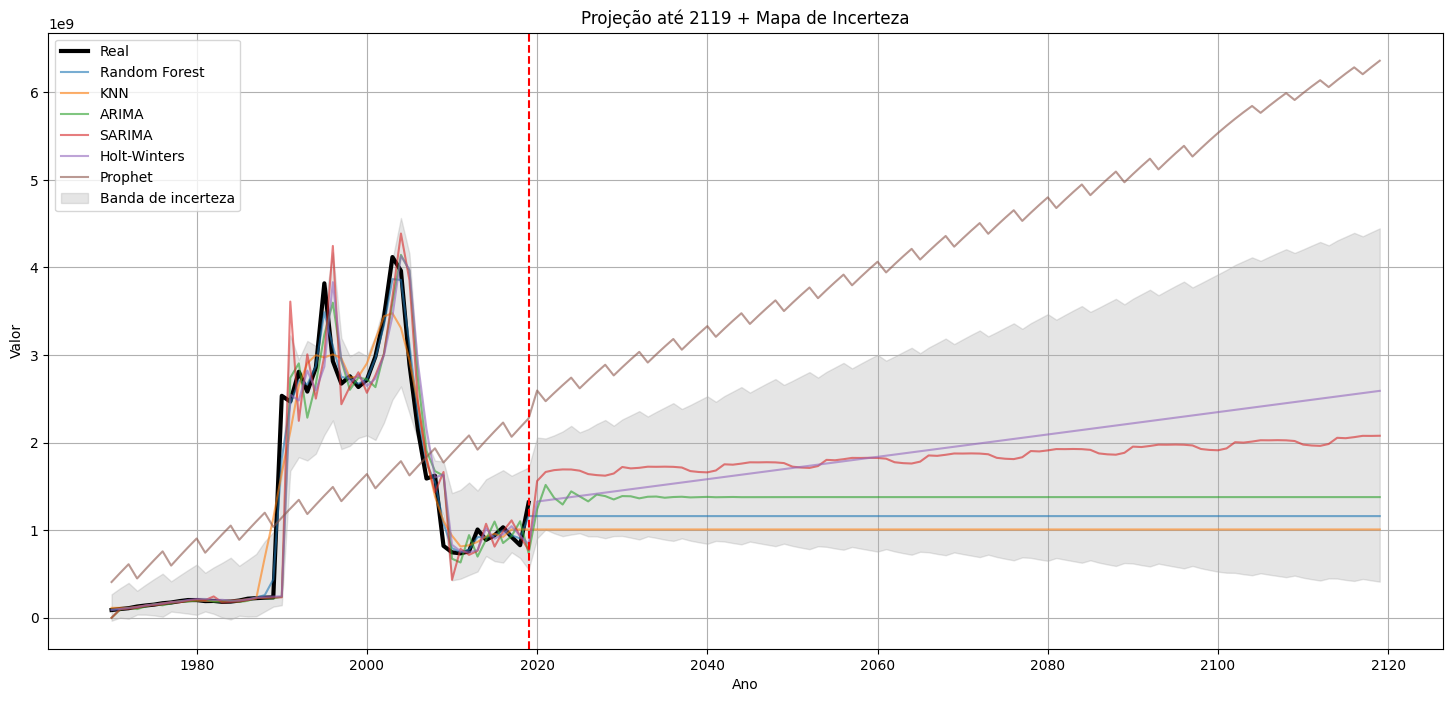

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# =========================
# DADOS
# =========================

anos = df_total["ano"].values.reshape(-1, 1)
y = np.array(y_total)

ano_final = df_total["ano"].max()
anos_futuros = np.arange(ano_final + 1, 2120).reshape(-1, 1)

# =========================
# FUNÇÃO DE ALERTA (EXPLOSÃO)
# =========================

def score_explosao(pred_hist, pred_future):
    crescimento = np.mean(np.abs(np.diff(pred_future)))
    erro_hist = np.mean(np.abs(pred_hist - y))

    return crescimento + erro_hist

# =========================
# MODELOS
# =========================

# RANDOM FOREST
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(anos, y)

rf_hist = rf.predict(anos)
rf_future = rf.predict(anos_futuros)

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(anos, y)

knn_hist = knn.predict(anos)
knn_future = knn.predict(anos_futuros)

# ARIMA
arima = ARIMA(y, order=(2,1,2)).fit()
arima_hist = arima.fittedvalues
arima_future = arima.forecast(len(anos_futuros))

# SARIMA
sarima = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_hist = sarima.fittedvalues
sarima_future = sarima.forecast(len(anos_futuros))

# HOLT-WINTERS
hw = ExponentialSmoothing(y, trend="add").fit()
hw_hist = hw.fittedvalues
hw_future = hw.forecast(len(anos_futuros))

# PROPHET
df_p = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y
})

prophet = Prophet()
prophet.fit(df_p)

future = prophet.make_future_dataframe(periods=len(anos_futuros), freq="YE")
forecast = prophet.predict(future)

prophet_hist = forecast["yhat"].iloc[:len(y)].values
prophet_future = forecast["yhat"].iloc[-len(anos_futuros):].values

# =========================
# DATAFRAME FINAL
# =========================

df_plot = pd.DataFrame({
    "Ano": np.concatenate([df_total["ano"].values, anos_futuros.flatten()]),
    "Real": np.concatenate([y, [np.nan]*len(anos_futuros)]),

    "RF": np.concatenate([rf_hist, rf_future]),
    "KNN": np.concatenate([knn_hist, knn_future]),
    "ARIMA": np.concatenate([arima_hist, arima_future]),
    "SARIMA": np.concatenate([sarima_hist, sarima_future]),
    "HoltWinters": np.concatenate([hw_hist, hw_future]),
    "Prophet": np.concatenate([prophet_hist, prophet_future]),
})

# =========================
# DETECÇÃO DE MODELOS INSTÁVEIS
# =========================

scores = {
    "RandomForest": score_explosao(rf_hist, rf_future),
    "KNN": score_explosao(knn_hist, knn_future),
    "ARIMA": score_explosao(arima_hist, arima_future),
    "SARIMA": score_explosao(sarima_hist, sarima_future),
    "HoltWinters": score_explosao(hw_hist, hw_future),
    "Prophet": score_explosao(prophet_hist, prophet_future),
}

df_score = pd.DataFrame(scores.items(), columns=["Modelo", "Score"])
df_score["Status"] = pd.cut(
    df_score["Score"],
    bins=[-np.inf, 0.5, 1.5, np.inf],
    labels=["VERDE (estável)", "AMARELO", "VERMELHO (instável)"]
)

print(df_score.sort_values("Score"))

# =========================
# BANDA DE INCERTEZA
# =========================

df_plot["Media_Modelos"] = df_plot[["RF","KNN","ARIMA","SARIMA","HoltWinters","Prophet"]].mean(axis=1)
df_plot["Desvio"] = df_plot[["RF","KNN","ARIMA","SARIMA","HoltWinters","Prophet"]].std(axis=1)

# =========================
# GRÁFICO FINAL
# =========================

plt.figure(figsize=(18,8))

plt.plot(df_plot["Ano"], df_plot["Real"], label="Real", linewidth=3, color="black")

plt.plot(df_plot["Ano"], df_plot["RF"], alpha=0.6, label="Random Forest")
plt.plot(df_plot["Ano"], df_plot["KNN"], alpha=0.6, label="KNN")
plt.plot(df_plot["Ano"], df_plot["ARIMA"], alpha=0.6, label="ARIMA")
plt.plot(df_plot["Ano"], df_plot["SARIMA"], alpha=0.6, label="SARIMA")
plt.plot(df_plot["Ano"], df_plot["HoltWinters"], alpha=0.6, label="Holt-Winters")
plt.plot(df_plot["Ano"], df_plot["Prophet"], alpha=0.6, label="Prophet")

# banda de incerteza
plt.fill_between(
    df_plot["Ano"],
    df_plot["Media_Modelos"] - df_plot["Desvio"],
    df_plot["Media_Modelos"] + df_plot["Desvio"],
    color="gray",
    alpha=0.2,
    label="Banda de incerteza"
)

plt.axvline(ano_final, linestyle="--", color="red")

plt.title("Projeção até 2119 + Mapa de Incerteza")
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()

01:10:51 - cmdstanpy - INFO - Chain [1] start processing
01:10:52 - cmdstanpy - INFO - Chain [1] done processing


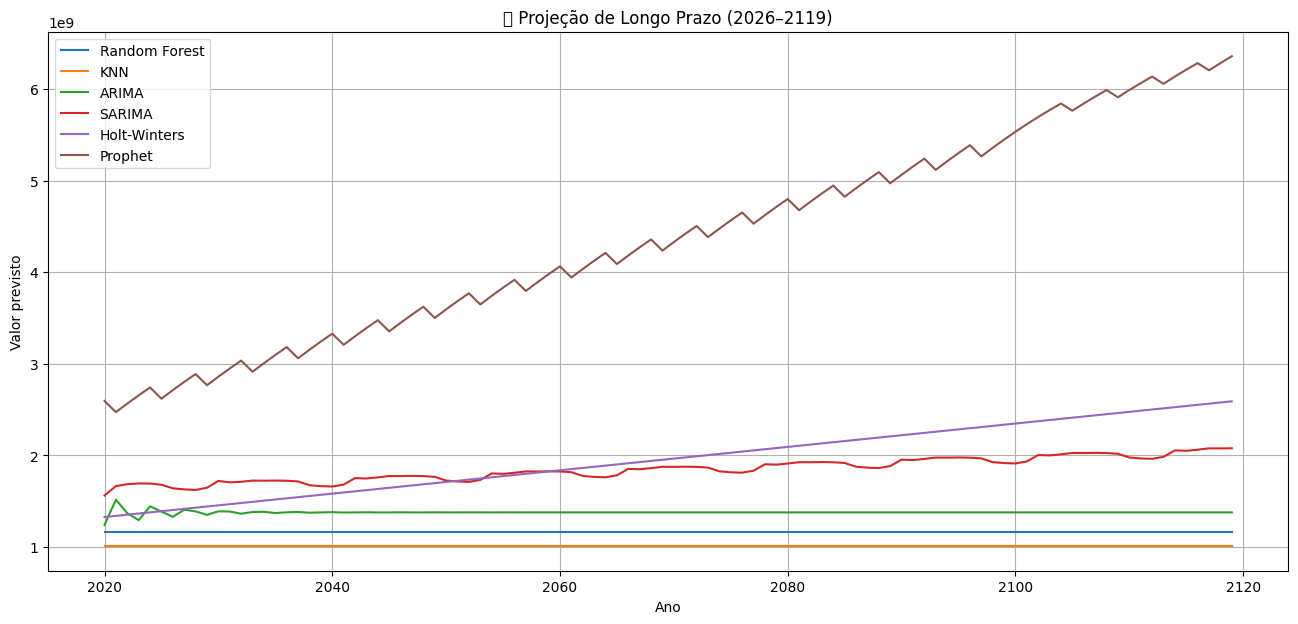

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# ============================================================
# DADOS
# ============================================================

X = df_total[["ano"]].values
y = np.array(y_total)

ano_final = df_total["ano"].max()

# 👉 PROJEÇÃO LONGA ATÉ 2119
anos_futuros = np.arange(ano_final + 1, 2120).reshape(-1, 1)

# ============================================================
# RANDOM FOREST (baseline)
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
rf_future = rf.predict(anos_futuros)

# ============================================================
# KNN
# ============================================================

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X, y)
knn_future = knn.predict(anos_futuros)

# ============================================================
# ARIMA
# ============================================================

arima = ARIMA(y, order=(2,1,2)).fit()
arima_future = arima.forecast(len(anos_futuros))

# ============================================================
# SARIMA
# ============================================================

sarima = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_future = sarima.forecast(len(anos_futuros))

# ============================================================
# HOLT-WINTERS
# ============================================================

hw = ExponentialSmoothing(y, trend="add").fit()
hw_future = hw.forecast(len(anos_futuros))

# ============================================================
# PROPHET (CORRIGIDO - SEM ERRO DE FREQUÊNCIA)
# ============================================================

df_p = pd.DataFrame({
    "ds": pd.to_datetime(df_total["ano"].astype(str) + "-01-01"),
    "y": y
})

prophet = Prophet()
prophet.fit(df_p)

future = prophet.make_future_dataframe(
    periods=len(anos_futuros),
    freq="YE"   # 🔥 corrigido (não usar "Y")
)

forecast = prophet.predict(future)

prophet_future = forecast["yhat"].iloc[-len(anos_futuros):].values

# ============================================================
# DATAFRAME FUTURO (ZOOM REAL)
# ============================================================

anos_plot = anos_futuros.flatten()

df_future = pd.DataFrame({
    "Ano": anos_plot,
    "RandomForest": rf_future,
    "KNN": knn_future,
    "ARIMA": arima_future,
    "SARIMA": sarima_future,
    "HoltWinters": hw_future,
    "Prophet": prophet_future
})

# ============================================================
# GRÁFICO (SÓ FUTURO)
# ============================================================

plt.figure(figsize=(16,7))

plt.plot(df_future["Ano"], df_future["RandomForest"], label="Random Forest")
plt.plot(df_future["Ano"], df_future["KNN"], label="KNN")
plt.plot(df_future["Ano"], df_future["ARIMA"], label="ARIMA")
plt.plot(df_future["Ano"], df_future["SARIMA"], label="SARIMA")
plt.plot(df_future["Ano"], df_future["HoltWinters"], label="Holt-Winters")
plt.plot(df_future["Ano"], df_future["Prophet"], label="Prophet")

plt.title("🔮 Projeção de Longo Prazo (2026–2119)")
plt.xlabel("Ano")
plt.ylabel("Valor previsto")
plt.grid(True)
plt.legend()

plt.show()

In [77]:
import numpy as np
import pandas as pd

# ============================================================
# FUNÇÃO DE ESTABILIDADE
# ============================================================

def estabilidade_score(hist, fut):

    hist = np.array(hist)
    fut = np.array(fut)

    # 1. variação no futuro (instabilidade)
    variacao = np.std(np.diff(fut))

    # 2. tendência extrema (derivada média)
    tendencia = np.mean(np.abs(np.diff(fut)))

    # 3. desvio do nível histórico
    drift = np.abs(np.mean(fut) - np.mean(hist))

    # score final (quanto MENOR, mais estável)
    score = variacao + tendencia + drift

    return score

# ============================================================
# CALCULAR PARA CADA MODELO
# (usa variáveis já geradas na célula anterior)
# ============================================================

ranking = []

ranking.append({
    "Modelo": "Random Forest",
    "Score": estabilidade_score(rf_hist, rf_future)
})

ranking.append({
    "Modelo": "KNN",
    "Score": estabilidade_score(knn_hist, knn_future)
})

ranking.append({
    "Modelo": "ARIMA",
    "Score": estabilidade_score(arima_hist, arima_future)
})

ranking.append({
    "Modelo": "SARIMA",
    "Score": estabilidade_score(sarima_hist, sarima_future)
})

ranking.append({
    "Modelo": "Holt-Winters",
    "Score": estabilidade_score(hw_hist, hw_future)
})

ranking.append({
    "Modelo": "Prophet",
    "Score": estabilidade_score(prophet_hist, prophet_future)
})

# ============================================================
# DATAFRAME E RANKING
# ============================================================

df_rank = pd.DataFrame(ranking)

df_rank = df_rank.sort_values("Score")

# classificação qualitativa
df_rank["Estabilidade"] = pd.cut(
    df_rank["Score"],
    bins=[-np.inf, df_rank["Score"].quantile(0.33),
          df_rank["Score"].quantile(0.66), np.inf],
    labels=["🟢 Alta", "🟡 Média", "🔴 Baixa"]
)

print("\n🏆 RANKING DE ESTABILIDADE (menor score = melhor)\n")
display(df_rank)


🏆 RANKING DE ESTABILIDADE (menor score = melhor)



,Modelo,Score,Estabilidade
2,ARIMA,1.097560e+08,🟢 Alta
0,Random Forest,1.721389e+08,🟢 Alta
1,KNN,3.306956e+08,🟡 Média
3,SARIMA,5.662939e+08,🟡 Média
4,Holt-Winters,6.433480e+08,🔴 Baixa
5,Prophet,3.212023e+09,🔴 Baixa
